# Networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [1]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [2]:
# Install libraries into the current kernel
%pip install duckdb duckdb-engine jupysql --quiet

# Load and connect to DuckDB
%load_ext sql
%sql duckdb:///:memory:


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /home/my_venvs/data_analysis/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Connecting to 'duckdb:///:memory:'

In [3]:
### this library allows to do SQL queries on dataframes
import duckdb

In [4]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql
import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [5]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [6]:

import network_analysis_functions as naf
import bivariate_library as bl

In [7]:
print(reload(naf))  

<module 'network_analysis_functions' from '/home/my_venvs/LOD_NicoSidler/notebooks_jupyter/wikidata_exploration/../network_analysis_functions.py'>


In [8]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


We use in this notebook the network data prepared in these two files:
* Get the [relationships with SPARQL](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.md)
* Prepare the [SQL view and export the data to CSV](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.sql)


Regarding persons, we reuse the file with the persons, their periods of activity and coded countries, that we created in the correspondence analysis chapter.




#### Get the network data

In [9]:
### Import information about relations to organisations - df_po

csv_address='da_data/da6-persons-organisations-relations.csv'
df_po = pd.read_csv(csv_address)
df_po.head(3)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q23785357,Burschenschaft Germania Erlangen,membership
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,employment
2,http://www.wikidata.org/entity/Q1000348,http://www.wikidata.org/entity/Q696757,University of Duisburg-Essen,employment


In [10]:
### Inspect the dataframe and 
# notably if there are missing values
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29791 entries, 0 to 29790
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          29791 non-null  object
 1   organisation_uri    29791 non-null  object
 2   organisation_label  29791 non-null  object
 3   relationship        29791 non-null  object
dtypes: object(4)
memory usage: 931.1+ KB


In [11]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_po.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,13145
employment,13768
membership,2878


#### Get the data about persons

In [12]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='da_data/da4-AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,23,Northern America,US,United States,United States,USA,United States Can.,1851,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,22,Western Europe,FR,France,France,FRA,France,1846,1846-1870
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,22,Western Europe,FR,France,France,FRA,France,1851,1846-1870


In [13]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           7917 non-null   object
 1   labelPer         7917 non-null   object
 2   birthYear        7917 non-null   int64 
 3   gender           7917 non-null   object
 4   labelPlace       7917 non-null   object
 5   geometry         7917 non-null   object
 6   uriPlace         7917 non-null   object
 7   FID              7917 non-null   int64 
 8   REGION           7917 non-null   object
 9   CNTR_ID          7917 non-null   object
 10  CNTR_NAME        7917 non-null   object
 11  NAME_ENGL        7917 non-null   object
 12  ISO3_CODE        7917 non-null   object
 13  coded_country    7917 non-null   object
 14  activityYear     7917 non-null   int64 
 15  periodsActivity  7518 non-null   object
dtypes: int64(3), object(13)
memory usage: 989.8+ KB


#### Writing SQL queries with the duckdb library

In [14]:
### Distribution of coded countries
dfc=pd.DataFrame(df_p.groupby(by=['coded_country']).size())
dfc.sort_values(by=0,ascending=False)


,0
coded_country,
Germany,1604
United States Can.,994
France,579
Italy,559
Poland,511
Austria Hungary,489
Czechia,484
Central Europe,466
South America,412


In [15]:
### Distribution of coded countries
dfc=duckdb.query("""
    SELECT coded_country, COUNT(*) as num
    FROM df_p
    GROUP BY coded_country
    ORDER BY num DESC
  """).to_df()
dfc

,coded_country,num
0,Germany,1604
1,United States Can.,994
2,France,579
3,Italy,559
4,Poland,511
5,Austria Hungary,489
6,Czechia,484
7,Central Europe,466
8,South America,412
9,Spain Port.,393


### Merge the two dataframes

This will restrict the information about relations to the persons that are present in the *da4-AFC.csv* file, i.e. only those with coded countries

In [16]:
df_p=df_p[['uriPer', 'labelPer', 'gender', 'birthYear','coded_country', 'periodsActivity']]
df_p=df_p.rename(columns={'uriPer':'person_uri'})
df_p.head(3)

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,male,1806,United States Can.,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,male,1801,France,1846-1870
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,male,1806,France,1846-1870


In [17]:
### Merge the two dataframes:
# only relations that involve persons in df_p
# will remain
df_rel=df_p.merge(df_po,on='person_uri')


In [18]:
print(len(df_rel))
df_rel.head(2)

15924


,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,male,1806,France,1846-1870,http://www.wikidata.org/entity/Q1189954,Mines ParisTech,education
1,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,male,1806,France,1846-1870,http://www.wikidata.org/entity/Q273626,École polytechnique,education


In [19]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,6630
employment,7251
membership,2043


In [20]:
### Number of persons
print(f"Number of persons with relations: {len(df_rel['person_uri'].unique())}")


Number of persons with relations: 5485


In [21]:
### Count number of relations per person
df_pn=pd.DataFrame(df_rel.groupby(by='person_uri').size().sort_values(ascending=False))
df_pn.columns=['number']
### Merge for inspection
df_pp=df_pn.merge(df_p, left_index=True, right_on='person_uri')
df_pp.iloc[:10]

,number,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
1023,20,http://www.wikidata.org/entity/Q160640,Raymond Aron,male,1905,France,1946-1970
5031,18,http://www.wikidata.org/entity/Q310161,Manuel Castells,male,1942,Spain Port.,1971-1995
1766,17,http://www.wikidata.org/entity/Q231349,Mary Douglas,female,1921,Italy,1946-1970
332,16,http://www.wikidata.org/entity/Q158060,W. E. B. Du Bois,male,1868,United States Can.,1896-1920
2031,15,http://www.wikidata.org/entity/Q553449,Thomas Sowell,male,1930,United States Can.,1971-1995
1889,15,http://www.wikidata.org/entity/Q76959,Ralf Dahrendorf,male,1929,Germany,1971-1995
1866,15,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,male,1929,Germany,1971-1995
7766,15,http://www.wikidata.org/entity/Q43632352,Maurizio Alì,male,1979,Italy,NaN
5663,15,http://www.wikidata.org/entity/Q1714580,Jutta Allmendinger,female,1956,Germany,1996-2020
239,14,http://www.wikidata.org/entity/Q9387,Max Weber,male,1864,Germany,1896-1920


In [22]:
### same query in SQL
df_pp = duckdb.query("""
    with tw1 AS (
    SELECT person_uri, COUNT(*) as number
    FROM df_rel
    GROUP BY person_uri
    )
    SELECT labelPer,number, birthYear,coded_country,periodsActivity
    from tw1 join df_p on df_p.person_uri = tw1.person_uri
    ORDER BY number DESC
    LIMIT 10
""").to_df()
df_pp

,labelPer,number,birthYear,coded_country,periodsActivity
0,Raymond Aron,20,1905,France,1946-1970
1,Manuel Castells,18,1942,Spain Port.,1971-1995
2,Mary Douglas,17,1921,Italy,1946-1970
3,W. E. B. Du Bois,16,1868,United States Can.,1896-1920
4,Jürgen Habermas,15,1929,Germany,1971-1995
5,Thomas Sowell,15,1930,United States Can.,1971-1995
6,Maurizio Alì,15,1979,Italy,None
7,Jutta Allmendinger,15,1956,Germany,1996-2020
8,Ralf Dahrendorf,15,1929,Germany,1971-1995
9,Max Weber,14,1864,Germany,1896-1920


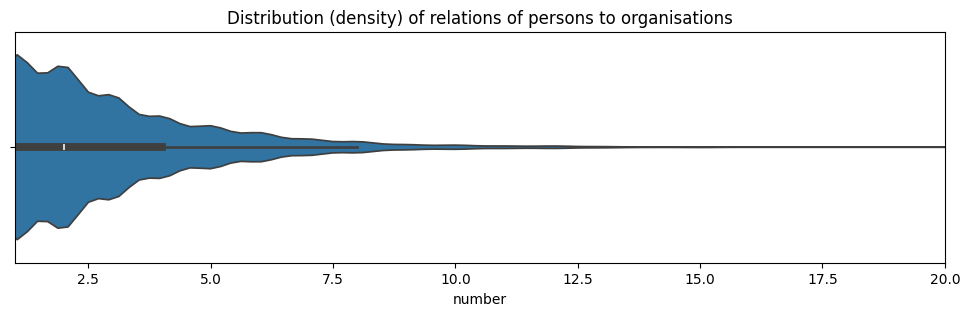

In [23]:
# Plot the distribution number of relations to organisations

min_val = df_pn.number.min()
max_val = df_pn.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df_pn.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Inspect the most connected persons

In [24]:
### Persons that have 10 or more relations to organisations
print(len(df_pn[df_pn.number > 9]))

100


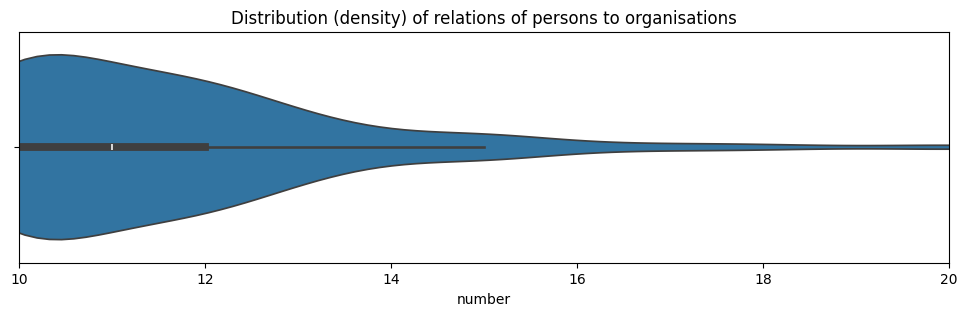

In [25]:
# Plot the distribution number of relations to organisations

df=df_pn[df_pn.number > 9]

min_val = df.number.min()
max_val = df.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

In [26]:
### Number of types of relationships, all the persons
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']

### Type of relationship of the 700 more connected persons (merge on the fly)
df_pn[df_pn.number > 9].merge(df_rel, left_index=True, right_on='person_uri').groupby(by='relationship').size()

df_rela_type=df_rela_type.join((df_pn[df_pn.number > 9].\
                   merge(df_rel, left_index=True, right_on='person_uri').groupby(by='relationship').size()).rename('rel_700'))

### Add the proportion between all the relations and those of the most connected persons
df_rela_type['prop']=df_rela_type.apply(lambda x: x['rel_700']/x['number'], axis=1)
### We observe that memberships are overrepresented for this very well known persons
df_rela_type


,number,rel_700,prop
relationship,,,
education,6630,296,0.044646
employment,7251,527,0.072680
membership,2043,338,0.165443


### Distribution of relationships with organisations in relation to activity periods

Observe if periods are specific to relations and which ones 

In [27]:
### Distribution of RELATIONS by periods of activity
activities_per = pd.DataFrame(df_rel.groupby(by='periodsActivity').size())
activities_per.columns=['number_rel']
print(activities_per)

                 number_rel
periodsActivity            
1846-1870                77
1871-1895               261
1896-1920               660
1921-1945              1144
1946-1970              2409
1971-1995              6516
1996-2020              4241


In [28]:
### Distribution of PERSONS by periods of activity
period_per = pd.DataFrame(df_p.groupby(by='periodsActivity').size())
period_per.columns=['number_per']
print(period_per)

                 number_per
periodsActivity            
1846-1870                36
1871-1895               100
1896-1920               278
1921-1945               460
1946-1970              1005
1971-1995              3202
1996-2020              2437


In [29]:
df_ap_per=activities_per.join(period_per)

### Number of activities divided by number of persons
df_ap_per['proportion']=df_ap_per.apply(lambda x: x.number_rel/x.number_per, axis=1).round(3)
df_ap_per

,number_rel,number_per,proportion
periodsActivity,,,
1846-1870,77,36,2.139
1871-1895,261,100,2.610
1896-1920,660,278,2.374
1921-1945,1144,460,2.487
1946-1970,2409,1005,2.397
1971-1995,6516,3202,2.035
1996-2020,4241,2437,1.740


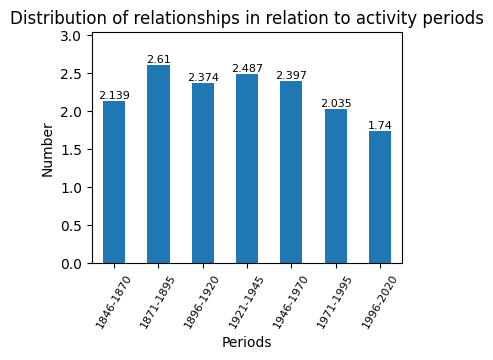

In [30]:
### Plot the evolution in time


ax = df_ap_per.proportion.plot(kind='bar',rot=50, fontsize=10, figsize=(4,3))
ax.bar_label(ax.containers[-1], size=8)


current_min, current_max = ax.get_ylim()
ax.set_ylim(current_min, current_max+0.3)

# Rotate labels 60 degrees and reduce font size
plt.xticks(rotation=60, fontsize=8)

plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Distribution of relationships in relation to activity periods')
plt.show()

In [31]:
### Create a cross-table
crosstab = pd.crosstab(df_rel['periodsActivity'],df_rel['relationship'])
# Optional: Remove the index name if you want a cleaner look
# crosstab.index.name = None
crosstab.columns.name = None
crosstab


,education,employment,membership
periodsActivity,,,
1846-1870,30,11,36
1871-1895,98,86,77
1896-1920,283,224,153
1921-1945,444,510,190
1946-1970,967,1054,388
1971-1995,2654,3083,779
1996-2020,1869,2009,363


In [32]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: True


In [33]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 341.23 , dof : 12
p-value : 0.0
Inertia (Phi-square):  0.022
Cramer:  0.106


#### Comment

A relation appears between type of relation and period. It is not strong but present, as we can observe in the heatmap of adjusted residuals: membership tends to be proportionally more present in the 19th century, while study and employment are more present in the 20th century. 

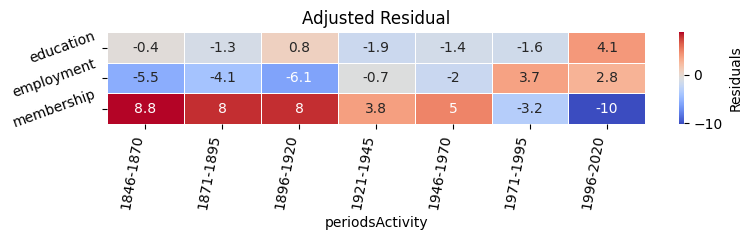

In [34]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 2.5))

## Relationships with organisations in relation to periods

### Universities - education

In [35]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='education']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

In [36]:
### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct


Number of persons per organisation and period: 1660


periodsActivity,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
University of Chicago,0,0,10,21,42,43,14,130
Harvard University,0,0,5,11,27,60,19,122
Columbia University,0,0,6,25,32,35,7,105
Eötvös Loránd University,0,1,1,8,4,36,51,101
University of Tokyo,0,0,3,4,9,38,35,89
University of Warsaw,0,1,1,3,13,44,26,88
"University of California, Berkeley",0,0,1,4,12,42,15,74
London School of Economics and Political Science,0,0,2,7,20,32,10,71
University of Vienna,0,1,10,13,15,16,15,70
School for Advanced Studies in the Social Sciences,0,0,0,0,2,28,29,59


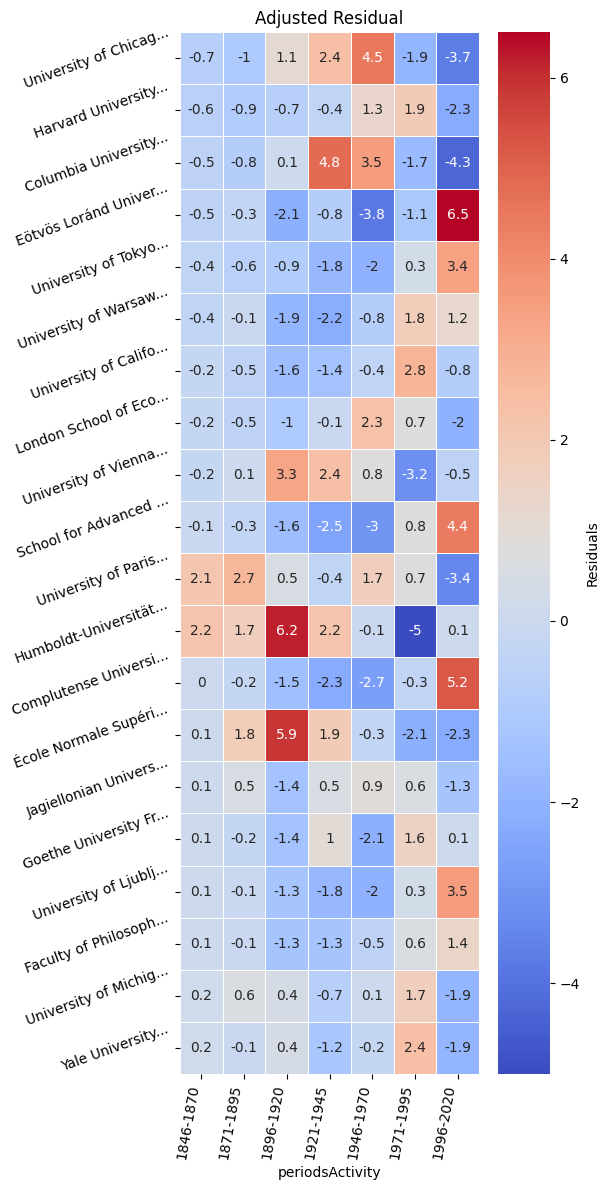

In [37]:
cct.index=[e[:20]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Employers

In [38]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='employment']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 2086


periodsActivity,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
Harvard University,0,0,2,9,27,38,10,86
University of Chicago,0,1,12,23,22,22,4,84
Columbia University,0,0,3,17,22,31,8,81
University of Warsaw,0,0,1,4,17,32,19,73
National Center for Scientific Research,0,0,0,0,7,40,26,73
Goethe University Frankfurt,0,0,1,15,10,27,12,65
Freie Universität Berlin,0,0,1,5,8,36,13,63
Humboldt-Universität zu Berlin,0,2,10,11,4,16,14,57
London School of Economics and Political Science,0,0,5,5,11,21,9,51
"University of California, Berkeley",0,0,0,4,14,26,7,51


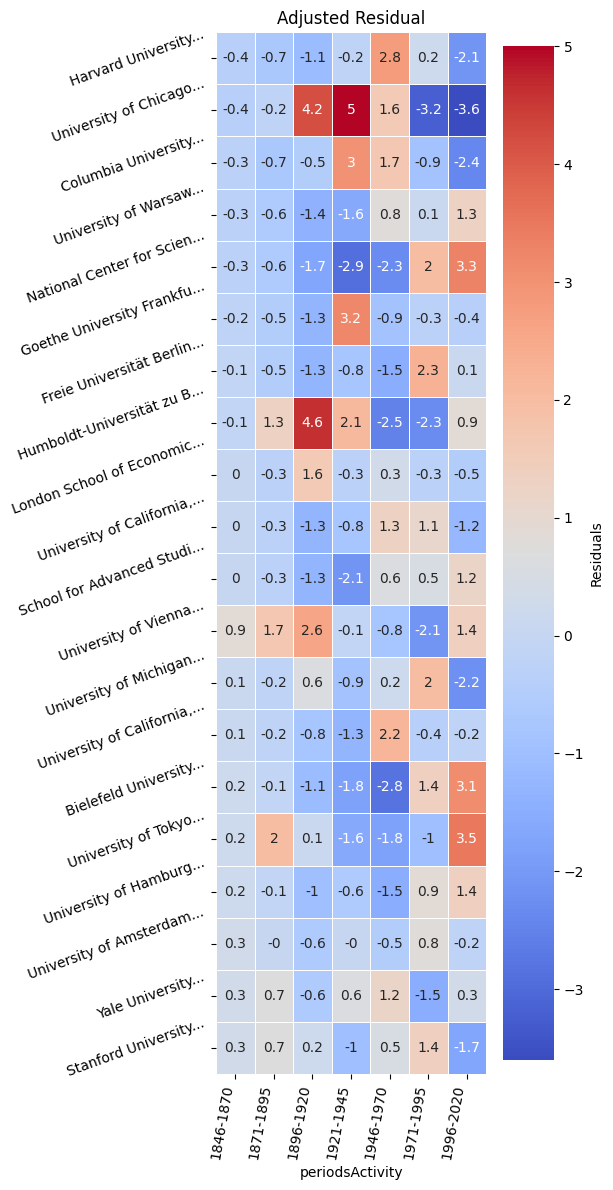

In [39]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Memberships

In [40]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='membership']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['periodsActivity'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 711


periodsActivity,1846-1870,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020,sum
American Academy of Arts and Sciences,3,1,8,19,71,72,14,188
Academia Europaea,0,0,0,0,9,47,24,80
National Academy of Sciences,1,0,1,5,24,22,4,57
American Philosophical Society,0,1,3,11,24,11,1,51
Polish Sociological Association,0,0,0,1,15,17,6,39
British Academy,0,0,0,3,13,18,2,36
Accademia Nazionale dei Lincei,4,5,3,8,3,7,2,32
Romanian Academy,1,2,5,11,9,3,0,31
Hungarian Academy of Sciences,0,1,2,5,5,13,2,28
Sozialistischer Deutscher Studentenbund,0,0,0,0,0,28,0,28


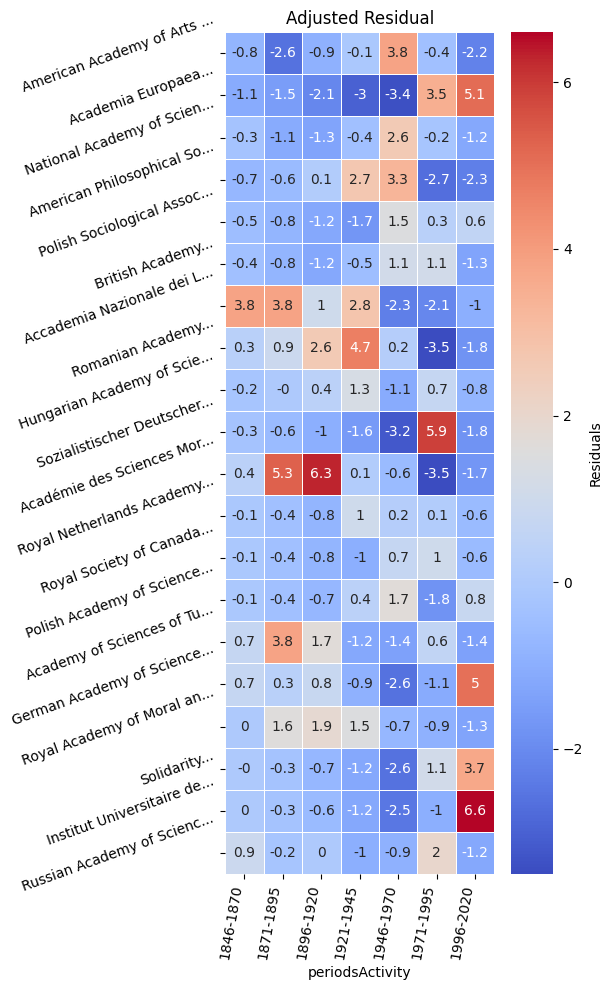

In [41]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,10))

## Add years to approximate possible relations


In this exercice we artificially build relationships between persons without providing a measure of their real match to reality. In a heuristic perspective, the aim is just to have a consistent network in view of applying some analysis techniques.


We model artificial or imputed encounters based on the idea that persons present in the same institutions in the same period virtually know each other. But this is not alway the case although it allows to build person networks around organisations.

In [42]:
### fonction that codes the year of begin of an 'encounter'
def code_year_begin(type_relation, year):
    if type_relation=='education':
        begin=int(year)+20
    elif type_relation=='employment':
        begin=int(year)+28
    elif type_relation=='membership':
        begin=int(year)+40
    else :
        begin = 0

    return begin    

In [43]:
### function that codes the year of end of the virtual "encounter"
def code_year_end(type_relation, year):
    if type_relation=='education':
        end=int(year)+28
    elif type_relation=='employment':
        end=int(year)+65
    elif type_relation=='membership':
        end=int(year)+65
    else :
        end = 0
        
    return end

In [44]:
### Apply the functions 
df_rel['year_begin'] = df_rel.apply(lambda x : code_year_begin(x['relationship'], x['birthYear']), axis=1)
df_rel['year_end'] = df_rel.apply(lambda x : code_year_end(x['relationship'], x['birthYear']), axis=1)

In [45]:
df_rel[df_rel.relationship=='membership'].iloc[10:15]

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity,organisation_uri,organisation_label,relationship,year_begin,year_end
25,http://www.wikidata.org/entity/Q313458,Lewis H. Morgan,male,1818,United States Can.,1846-1870,http://www.wikidata.org/entity/Q4742987,American Antiquarian Society,membership,1858,1883
26,http://www.wikidata.org/entity/Q444472,Ion Ghica,male,1816,Central Europe,1846-1870,http://www.wikidata.org/entity/Q901677,Romanian Academy,membership,1856,1881
27,http://www.wikidata.org/entity/Q34787,Friedrich Engels,male,1820,Germany,1846-1870,http://www.wikidata.org/entity/Q183725,International Workingmen's Association,membership,1860,1885
29,http://www.wikidata.org/entity/Q37103,Florence Nightingale,female,1820,Italy,1846-1870,http://www.wikidata.org/entity/Q1692699,Royal Statistical Society,membership,1860,1885
30,http://www.wikidata.org/entity/Q144535,Herbert Spencer,male,1820,United Kingdom,1846-1870,http://www.wikidata.org/entity/Q1316663,X Club,membership,1860,1885


## Create pairs of persons: education

Create relations of persons through relations to organisations

In [46]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='education'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

6630


In [47]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_edu = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_edu))

178170


In [48]:
### Inspect
merged_edu.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,1951,1959,1971-1995
1,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q107274626,János Ladányi,1969,1977,1971-1995


In [49]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_edu = merged_edu[merged_edu['person_uri_x'] < (merged_edu['person_uri_y'])]
print(len(merged_edu), '-', len(merged_edu)*2)

85770 - 171540


In [50]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_edu = merged_edu[(merged_edu['year_begin_y'] < merged_edu['year_end_x']) & (merged_edu['year_begin_x'] < merged_edu['year_end_y'])]
print(len(merged_edu))

## We observe that linked people are not necessarily in the same activity period
merged_edu.head(3)


17340


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
22,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q51880715,Sándor Kávássy,1954,1962,1971-1995
24,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q851164,Corvinus University of Budapest,1951,1959,1971-1995,http://www.wikidata.org/entity/Q538477,Iván Szelényi,1958,1966,1971-1995
35,http://www.wikidata.org/entity/Q100146726,Nicolas Bourgoin,http://www.wikidata.org/entity/Q273518,School for Advanced Studies in the Social Scie...,1982,1990,1996-2020,http://www.wikidata.org/entity/Q113780121,Thomas Périlleux,1985,1993,1996-2020


In [51]:
gbe_edu = duckdb.query("""
    
    SELECT organisation_label, COUNT(*) as number
    FROM merged_edu
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_edu.iloc[:10]

,organisation_label,number
0,Harvard University,1347
1,University of Chicago,1308
2,Eötvös Loránd University,1260
3,University of Warsaw,907
4,Columbia University,896
5,University of Tokyo,863
6,"University of California, Berkeley",672
7,School for Advanced Studies in the Social Scie...,572
8,London School of Economics and Political Science,477
9,Complutense University of Madrid,398


### Create network of persons relationships during studies

#### Example of connected persons

Displayed with **Allegrograph Gruff**

<img src="images/alg_gruff_example_chinese_connected_education.png" alt="drawing" width="700"/>

In [52]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_edu = merged_edu.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_edu['number'] = gr_edu.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_edu))


16610


In [53]:
gr_edu=gr_edu.reset_index()
gr_edu.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
16575,http://www.wikidata.org/entity/Q95141122,http://www.wikidata.org/entity/Q95183273,1946-1970,1921,1929,1926,1934,1946-1970,"Faculty of Arts, Charles University in Prague|...",http://www.wikidata.org/entity/Q3563550|http:/...,3
4023,http://www.wikidata.org/entity/Q1177958,http://www.wikidata.org/entity/Q129948807,1996-2020,1974,1982,1973,1981,1996-2020,Harvard University|Eötvös Loránd University|Co...,http://www.wikidata.org/entity/Q13371|http://w...,3
7024,http://www.wikidata.org/entity/Q156268,http://www.wikidata.org/entity/Q333686,1971-1995,1950,1958,1945,1953,1946-1970,Lycée Louis-le-Grand|École Normale Supérieure,http://www.wikidata.org/entity/Q1059546|http:/...,2
11770,http://www.wikidata.org/entity/Q3027008,http://www.wikidata.org/entity/Q3591013,1996-2020,1975,1983,1978,1986,1996-2020,School for Advanced Studies in the Social Scie...,http://www.wikidata.org/entity/Q273518|http://...,2
13364,http://www.wikidata.org/entity/Q4202056,http://www.wikidata.org/entity/Q7494007,1971-1995,1958,1966,1962,1970,1971-1995,University of Massachusetts Amherst|Harvard Un...,http://www.wikidata.org/entity/Q15142|http://w...,2


In [54]:
### change columns names
gr_edu.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_edu = gr_edu[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x',  'periodsActivity_y']]
gr_edu.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
16575,http://www.wikidata.org/entity/Q95141122,http://www.wikidata.org/entity/Q95183273,"Faculty of Arts, Charles University in Prague|...",3,http://www.wikidata.org/entity/Q3563550|http:/...,1946-1970,1946-1970
4023,http://www.wikidata.org/entity/Q1177958,http://www.wikidata.org/entity/Q129948807,Harvard University|Eötvös Loránd University|Co...,3,http://www.wikidata.org/entity/Q13371|http://w...,1996-2020,1996-2020


In [55]:
print('More then 2 relations:', len(gr_edu[gr_edu.orgs_number>2]), '\n2 relations:', len(gr_edu[gr_edu.orgs_number==2]),
      '\none relation:', len(gr_edu[gr_edu.orgs_number==1]))

More then 2 relations: 2 
2 relations: 213 
one relation: 16395


In [56]:

### Do not use

### Find persons in different periods

## We observe that there is significant overlap: more than 30000
# Periods are as a matter of fact an artificial construct !

#print(len(gr_mer[gr_mer.periodsActivity_x != gr_mer.periodsActivity_y]))
#gr_mer[gr_mer.periodsActivity_x != gr_mer.periodsActivity_y].sort_values(by='orgs_number', ascending=False).iloc[:5]

## Create pairs of persons: employment


Create relations of persons through relations to organisations

In [57]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='employment'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

7251


In [58]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_empl = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_empl))


127065


In [59]:
merged_empl.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1000087,Horst Baier,1961,1998,1971-1995
1,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1039705,Carl Mayer,1930,1967,1946-1970


In [60]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_empl = merged_empl[merged_empl['person_uri_x'] < (merged_empl['person_uri_y'])]
print(len(merged_empl), '-', len(merged_empl)*2)

59907 - 119814


In [61]:
### Restrict time overlap : from 28 to 65
# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_empl = merged_empl[(merged_empl['year_begin_y'] < merged_empl['year_end_x']) & (merged_empl['year_begin_x'] < merged_empl['year_end_y'])]
print(len(merged_empl))

## We observe that linked people are not necessarily in the same activity period
merged_empl.head(3)


43277


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
1,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1039705,Carl Mayer,1930,1967,1946-1970
3,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1078177,Christa Rohde-Dachser,1965,2002,1971-1995
4,http://www.wikidata.org/entity/Q1000087,Horst Baier,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,1961,1998,1971-1995,http://www.wikidata.org/entity/Q1081982,Christian Stegbauer,1988,2025,1996-2020


In [62]:
gbe_empl = duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_empl
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_empl.iloc[:5]

,organisation_label,number
0,Harvard University,2805
1,National Center for Scientific Research,2571
2,University of Warsaw,2317
3,Columbia University,2211
4,University of Chicago,2171


### Create network of persons relationships during emloyment

In [63]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_empl = merged_empl.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_empl['number'] = gr_empl.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_empl))


40859


In [64]:
gr_empl=gr_empl.reset_index()
gr_empl.sort_values(by='number', ascending=False).head(2)

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
28471,http://www.wikidata.org/entity/Q28316798,http://www.wikidata.org/entity/Q5478321,1971-1995,1974,2011,1988,2025,1996-2020,Stanford University|Duke University|University...,http://www.wikidata.org/entity/Q41506|http://w...,3
7307,http://www.wikidata.org/entity/Q1174707,http://www.wikidata.org/entity/Q5761098,1996-2020,1979,2016,1977,2014,1971-1995,London School of Economics and Political Scien...,http://www.wikidata.org/entity/Q174570|http://...,3


In [65]:
### change columns names
gr_empl.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_empl = gr_empl[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x', 'periodsActivity_y']]
gr_empl.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
28471,http://www.wikidata.org/entity/Q28316798,http://www.wikidata.org/entity/Q5478321,Stanford University|Duke University|University...,3,http://www.wikidata.org/entity/Q41506|http://w...,1971-1995,1996-2020
7307,http://www.wikidata.org/entity/Q1174707,http://www.wikidata.org/entity/Q5761098,London School of Economics and Political Scien...,3,http://www.wikidata.org/entity/Q174570|http://...,1996-2020,1971-1995


In [66]:
print('More then 2 relations:', len(gr_empl[gr_empl.orgs_number>2]), 
      '\n2 relations:', len(gr_empl[gr_empl.orgs_number==2]),
      '\n1 relations:', len(gr_empl[gr_empl.orgs_number==1]))

More then 2 relations: 19 
2 relations: 787 
1 relations: 40053


In [67]:
print(gr_empl.orgs_number.max())

3


## Create pairs of persons: membership

Create relations of persons through relations to organisations

In [68]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='membership'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'periodsActivity']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

2043


In [69]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_memb = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_memb))


63639


In [70]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_memb = merged_memb[merged_memb['person_uri_x'] < (merged_memb['person_uri_y'])]
print(len(merged_memb), '-', len(merged_memb)*2)

30798 - 61596


In [71]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_memb = merged_memb[(merged_memb['year_begin_y'] < merged_memb['year_end_x']) & (merged_memb['year_begin_x'] < merged_memb['year_end_y'])]
print(len(merged_memb))

## We observe that linked people are not necessarily in the same activity period
merged_memb.head(3)


18155


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,periodsActivity_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,periodsActivity_y
3,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1096729,István Imreh,1959,1984,1946-1970
4,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1105097,Viktor Karády,1976,2001,1971-1995
5,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1971,1996,1971-1995,http://www.wikidata.org/entity/Q1106778,István Kemény,1965,1990,1946-1970


In [72]:
### count relations by organisation
gbe_memb=duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_memb
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_memb.iloc[:5]

,organisation_label,number
0,American Academy of Arts and Sciences,9867
1,Academia Europaea,2497
2,National Academy of Sciences,943
3,American Philosophical Society,769
4,Polish Sociological Association,511


### Create network of persons relationships during membership

In [73]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_memb = merged_memb.groupby(by=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'periodsActivity_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_memb['number'] = gr_memb.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_memb))


16222


In [74]:
gr_memb=gr_memb.reset_index()
gr_memb.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,periodsActivity_x,year_begin_x,year_end_x,year_begin_y,year_end_y,periodsActivity_y,organisation_label,organisation_uri,number
10975,http://www.wikidata.org/entity/Q312843,http://www.wikidata.org/entity/Q76959,1946-1970,1950,1975,1969,1994,1971-1995,American Academy of Arts and Sciences|National...,http://www.wikidata.org/entity/Q463303|http://...,5
14395,http://www.wikidata.org/entity/Q539414,http://www.wikidata.org/entity/Q81244,1946-1970,1951,1976,1942,1967,1946-1970,Royal Society|National Academy of Sciences|Ame...,http://www.wikidata.org/entity/Q123885|http://...,4
15974,http://www.wikidata.org/entity/Q76959,http://www.wikidata.org/entity/Q83907,1971-1995,1969,1994,1955,1980,1946-1970,British Academy|National Academy of Sciences|A...,http://www.wikidata.org/entity/Q723551|http://...,4
10980,http://www.wikidata.org/entity/Q312843,http://www.wikidata.org/entity/Q83907,1946-1970,1950,1975,1955,1980,1946-1970,American Academy of Arts and Sciences|National...,http://www.wikidata.org/entity/Q463303|http://...,4
15665,http://www.wikidata.org/entity/Q713936,http://www.wikidata.org/entity/Q76959,1971-1995,1970,1995,1969,1994,1971-1995,Russian Academy of Sciences|American Philosoph...,http://www.wikidata.org/entity/Q83172|http://w...,4


In [75]:
### change columns names
gr_memb.columns=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'periodsActivity_y', 'orgs_labels', 'orgs_uris', 'orgs_number']

In [76]:
### change columns positions
gr_memb = gr_memb[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'periodsActivity_x', 'periodsActivity_y']]
gr_memb.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
10975,http://www.wikidata.org/entity/Q312843,http://www.wikidata.org/entity/Q76959,American Academy of Arts and Sciences|National...,5,http://www.wikidata.org/entity/Q463303|http://...,1946-1970,1971-1995
14395,http://www.wikidata.org/entity/Q539414,http://www.wikidata.org/entity/Q81244,Royal Society|National Academy of Sciences|Ame...,4,http://www.wikidata.org/entity/Q123885|http://...,1946-1970,1946-1970


In [77]:
print('More then 2 relations:', len(gr_memb[gr_memb.orgs_number>2]), 
      '\n2 relations:', len(gr_memb[gr_memb.orgs_number==2]),
      '\none relation:', len(gr_memb[gr_memb.orgs_number==1]))

More then 2 relations: 255 
2 relations: 1372 
one relation: 14595


In [78]:
print('More then 4 relations:', len(gr_memb[gr_memb.orgs_number>4]), 
      '\n4 relations:', len(gr_memb[gr_memb.orgs_number==4]),
      '\n3 relations:', len(gr_memb[gr_memb.orgs_number==3]))

More then 4 relations: 1 
4 relations: 9 
3 relations: 245


In [79]:
print('More then 10 relations:', len(gr_memb[gr_memb.orgs_number>10]), '\n10 relations:', len(gr_memb[gr_memb.orgs_number==10]))

More then 10 relations: 0 
10 relations: 0


In [80]:
print(gr_memb.orgs_number.max())

5


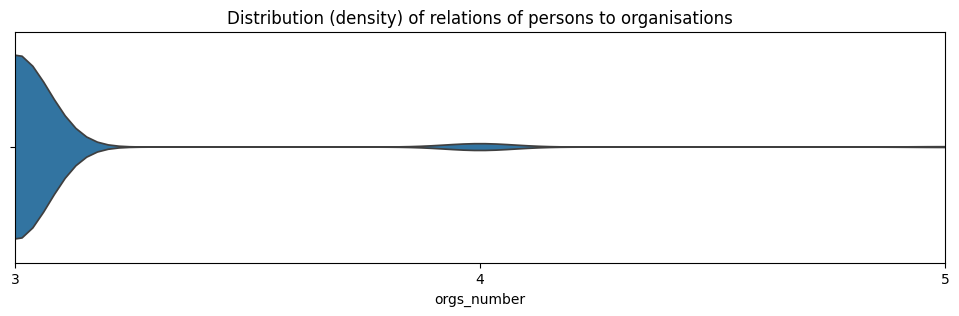

In [82]:
# Plot the distribution of eigenvector density

df=gr_memb[gr_memb.orgs_number>2]

min_val = df.orgs_number.min()
max_val = df.orgs_number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.orgs_number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

## Most frequent organisations as relations

Organisations where memberships' relationship happen are different from those where people are educated and are employed, as we can see if we compare the tables below.

We therefore just join educational institutions and employers

In [83]:
gbe_edu.head()

,organisation_label,number
0,Harvard University,1347
1,University of Chicago,1308
2,Eötvös Loránd University,1260
3,University of Warsaw,907
4,Columbia University,896


In [84]:
gbe_empl.head()

,organisation_label,number
0,Harvard University,2805
1,National Center for Scientific Research,2571
2,University of Warsaw,2317
3,Columbia University,2211
4,University of Chicago,2171


In [85]:
gbe_memb.head()

,organisation_label,number
0,American Academy of Arts and Sciences,9867
1,Academia Europaea,2497
2,National Academy of Sciences,943
3,American Philosophical Society,769
4,Polish Sociological Association,511


In [86]:
### Join first hundred organisation for education and employment

gb_organ_of_rel=pd.merge(left=gbe_edu, on='organisation_label', right=gbe_empl,
                suffixes=('_rel_edu', '_rel_empl'), how='outer')
gb_organ_of_rel[['number_rel_edu','number_rel_empl']]=gb_organ_of_rel[['number_rel_edu','number_rel_empl']].fillna(0).astype('int')
print(len(gb_organ_of_rel))
gb_organ_of_rel.head()

138


,organisation_label,number_rel_edu,number_rel_empl
0,Adam Mickiewicz University in Poznań,90,159
1,Autonomous University of Barcelona,49,157
2,Babeș-Bolyai University,28,0
3,Belarusian State University,0,101
4,Bielefeld University,0,727


In [87]:
gb_organ_of_rel.sort_values(by='number_rel_edu', ascending=False).iloc[:20]
#gb_organ_of_rel.sort_values(by='number_rel_empl', ascending=False).iloc[:30]


,organisation_label,number_rel_edu,number_rel_empl
25,Harvard University,1347,2805
89,University of Chicago,1308,2171
15,Eötvös Loránd University,1260,0
127,University of Warsaw,907,2317
9,Columbia University,896,2211
120,University of Tokyo,863,405
85,"University of California, Berkeley",672,1042
70,School for Advanced Studies in the Social Scie...,572,1083
46,London School of Economics and Political Science,477,847
10,Complutense University of Madrid,398,451


## Merge the three networks: where do the encounters happen?

We merge the three tables of relations (education, employment, membership) and observe where encounters happen.

In [88]:
network=pd.merge(gr_edu, gr_empl, on=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'periodsActivity_y'],
                 how='outer', suffixes=('_edu', '_empl'), indicator=True)

In [89]:
network.rename(columns={'_merge': 'merge_1'}, inplace=True)

In [90]:
network.sort_values(by='orgs_number_edu', ascending=False).head(3)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,orgs_uris_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_uris_empl,merge_1
56245,http://www.wikidata.org/entity/Q95141122,http://www.wikidata.org/entity/Q95183273,"Faculty of Arts, Charles University in Prague|...",3.0,http://www.wikidata.org/entity/Q3563550|http:/...,1946-1970,1946-1970,NaN,NaN,NaN,left_only
11519,http://www.wikidata.org/entity/Q1177958,http://www.wikidata.org/entity/Q129948807,Harvard University|Eötvös Loránd University|Co...,3.0,http://www.wikidata.org/entity/Q13371|http://w...,1996-2020,1996-2020,NaN,NaN,NaN,left_only
22153,http://www.wikidata.org/entity/Q156268,http://www.wikidata.org/entity/Q333686,Lycée Louis-le-Grand|École Normale Supérieure,2.0,http://www.wikidata.org/entity/Q1059546|http:/...,1971-1995,1946-1970,School for Advanced Studies in the Social Scie...,1.0,http://www.wikidata.org/entity/Q273518,both


In [91]:
network=pd.merge(network, gr_memb, on=['person_uri_x', 'person_uri_y', 'periodsActivity_x', 'periodsActivity_y' ],
                 how='outer', suffixes=('', '_memb'), indicator=True)

In [97]:
network.rename(columns={'organisation_label': 'orgs_labels_memb','number': 'orgs_number_memb','organisation_uri': 'orgs_uris_memb'}, inplace=True)

In [100]:
# 1. Rename the columns that came from the membership merge
network = network.rename(columns={
    'orgs_labels': 'orgs_labels_memb',
    'orgs_number': 'orgs_number_memb',
    'orgs_uris': 'orgs_uris_memb'
})

# 2. Now fill the NaNs and convert to integers
# We use a list to make it cleaner and avoid repetitive code
for col in ['orgs_number_edu', 'orgs_number_empl', 'orgs_number_memb']:
    if col in network.columns:
        network[col] = network[col].fillna(0).astype(int)

# Verify the result
print(network[['orgs_number_edu', 'orgs_number_empl', 'orgs_number_memb']].head())

   orgs_number_edu  orgs_number_empl  orgs_number_memb
0                0                 1                 0
1                0                 1                 0
2                0                 1                 0
3                0                 1                 0
4                0                 1                 0


In [101]:
print(network.columns.tolist())

['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'orgs_uris_edu', 'periodsActivity_x', 'periodsActivity_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_uris_empl', 'merge_1', 'orgs_labels_memb', 'orgs_number_memb', 'orgs_uris_memb', '_merge']


In [102]:
network['orgs_number_edu'].fillna(0, inplace=True)
network['orgs_number_empl'].fillna(0, inplace=True)
network['orgs_number_memb'].fillna(0, inplace=True)
network['orgs_number_memb']=network['orgs_number_memb'].astype(int)
network['orgs_number_edu']=network['orgs_number_edu'].astype(int)
network['orgs_number_empl']=network['orgs_number_empl'].astype(int)


In [103]:
network=network[['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'periodsActivity_x', 'periodsActivity_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_labels_memb', 'orgs_number_memb']]

In [104]:
network.iloc[550:555]

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb
550,http://www.wikidata.org/entity/Q1016499,http://www.wikidata.org/entity/Q14746173,University of Münster,1,1996-2020,1996-2020,NaN,0,NaN,0
551,http://www.wikidata.org/entity/Q1016499,http://www.wikidata.org/entity/Q15434616,University of Münster,1,1996-2020,1996-2020,NaN,0,NaN,0
552,http://www.wikidata.org/entity/Q1016499,http://www.wikidata.org/entity/Q2173895,NaN,0,1996-2020,1996-2020,NaN,0,North Rhine-Westphalia Academy for Sciences an...,1
553,http://www.wikidata.org/entity/Q1016499,http://www.wikidata.org/entity/Q22668286,University of Münster,1,1996-2020,1996-2020,NaN,0,NaN,0
554,http://www.wikidata.org/entity/Q1016499,http://www.wikidata.org/entity/Q85261,University of Münster,1,1996-2020,1996-2020,NaN,0,NaN,0


In [105]:
### create field with addition edu and empl
network['sum_edu_empl']=network['orgs_number_edu']+network['orgs_number_empl']

In [106]:
### create field with sum of all values
network['sum_all_rel']=network['orgs_number_edu']+network['orgs_number_empl']+network['orgs_number_memb']

#### Add persons' labels

In [107]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer']], left_on='person_uri_x', right_on='person_uri')

In [108]:
network.drop(columns=['person_uri'], inplace=True)

In [109]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer']], left_on='person_uri_y', right_on='person_uri', suffixes=('_x1', '_y'))


In [110]:
network.rename(columns={'labelPer_x1': 'labelPer_x'}, inplace=True)

In [111]:
network.drop(columns=['person_uri'], inplace=True)

In [112]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,periodsActivity_x,periodsActivity_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x,labelPer_y
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1039705,NaN,0,1971-1995,1946-1970,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,Carl Mayer
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1078177,NaN,0,1971-1995,1971-1995,Goethe University Frankfurt,1,NaN,0,1,1,Horst Baier,Christa Rohde-Dachser


In [113]:
### Change columns order
network=network[['labelPer_x',
  'labelPer_y',
'periodsActivity_x', 'periodsActivity_y',
 'sum_edu_empl', ### study and employment relationshipa
 'sum_all_rel', ### all the relationships
 'orgs_number_edu',  'orgs_labels_edu', 
 'orgs_number_empl', 'orgs_labels_empl',
 'orgs_number_memb', 'orgs_labels_memb',
 'person_uri_x', 'person_uri_y'
   ]]

In [114]:
### SQL Queries


# order by max sum of edu and empl relations
query_1="""
    SELECT *
    FROM network
    ORDER BY sum_edu_empl DESC
    LIMIT 5
"""


# order by max sum of all relations
query_2="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY sum_all_rel DESC
    --OFFSET 500
    LIMIT 10
"""



# order by max  edu and empl relations
query_3="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY orgs_number_empl DESC, orgs_number_edu DESC
    --OFFSET 500
    LIMIT 10
"""

In [115]:
duckdb.query(query_3).to_df()

,labelPer_x,labelPer_y,periodsActivity_x,periodsActivity_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Christine Musselin,Marc Lazar,1996-2020,1996-2020,4,4,1,Sciences Po,3,National Center for Scientific Research|Scienc...,0,None,http://www.wikidata.org/entity/Q2965956,http://www.wikidata.org/entity/Q3288191
1,Henryk Szlajfer,Bronisław Misztal,1971-1995,1971-1995,4,4,1,University of Warsaw,3,Polish Academy of Sciences|Ministry of Foreign...,0,None,http://www.wikidata.org/entity/Q3944641,http://www.wikidata.org/entity/Q9179828
2,Joachim Matthes,Lars Clausen,1971-1995,1971-1995,3,3,1,Freie Universität Berlin,2,University of Münster|Bielefeld University,0,None,http://www.wikidata.org/entity/Q1690305,http://www.wikidata.org/entity/Q99042
3,Tamotsu Shibutani,Nathan Keyfitz,1946-1970,1946-1970,3,3,1,University of Chicago,2,"University of California, Berkeley|University ...",0,None,http://www.wikidata.org/entity/Q11316354,http://www.wikidata.org/entity/Q6969175
4,Tamotsu Shibutani,Reinhard Bendix,1946-1970,1946-1970,3,3,1,University of Chicago,2,"University of California, Berkeley|University ...",0,None,http://www.wikidata.org/entity/Q11316354,http://www.wikidata.org/entity/Q76175
5,Maurice Zeitlin,Iván Szelényi,1971-1995,1971-1995,3,3,1,"University of California, Berkeley",2,"University of California, Los Angeles|Universi...",0,None,http://www.wikidata.org/entity/Q109557910,http://www.wikidata.org/entity/Q538477
6,Roland Barthes,Georges Balandier,1946-1970,1946-1970,3,3,1,Faculty of Arts of Paris,2,National Center for Scientific Research|School...,0,None,http://www.wikidata.org/entity/Q179109,http://www.wikidata.org/entity/Q657995
7,Hartmut Häußermann,Claus Offe,1971-1995,1971-1995,3,3,1,Freie Universität Berlin,2,University of Bremen|Humboldt-Universität zu B...,0,None,http://www.wikidata.org/entity/Q1311385,http://www.wikidata.org/entity/Q62725
8,Fermín Bouza Álvarez,María Ángeles Durán,1971-1995,1971-1995,3,3,1,University of Madrid,2,Autonomous University of Madrid|Complutense Un...,0,None,http://www.wikidata.org/entity/Q12388364,http://www.wikidata.org/entity/Q17478003
9,Douglas Massey,Andrew Scull,1996-2020,1971-1995,3,3,1,Princeton University,2,University of Pennsylvania|Princeton University,0,None,http://www.wikidata.org/entity/Q1252392,http://www.wikidata.org/entity/Q13427370


In [116]:
print('Tot:', len(network), 'Edu:', len
      (gr_edu), ', Empl:', len(gr_empl), ', Memb:', len(gr_memb))

Tot: 70338 Edu: 16610 , Empl: 40859 , Memb: 16222


count    139.000000
mean       4.057554
std        0.233740
min        4.000000
25%        4.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: sum_all_rel, dtype: float64


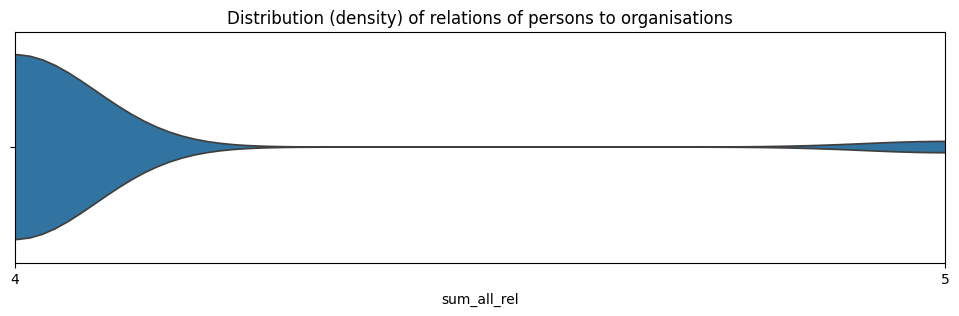

In [117]:
### We only consider in the distribution more than three
df=network[network.sum_all_rel>3]
print(df.sum_all_rel.describe())

### Plot the distribution of the total number of relations
# where there are more than 3 relations
min_val = df.sum_all_rel.min()
max_val = df.sum_all_rel.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.sum_all_rel, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Correlations

We could wonder if the fact of studying together, or working together would lead to be member of the same organisations.

Given the large amount of people having just one or to relation, we only consider people having at least four relationships.

We use here ranking correlation given that we are counting relations

Surprisingly:
* there is some weak positive relation between studying and working together
* but there is a stronger negative correlation between studying or working together and being member of same organisations 


In [118]:
df=network[network.sum_all_rel>3]
print(len(df))

139


In [126]:
# Save the dataframe directly into the folder visible in your sidebar
df.to_csv('da_data/network_analysis_results.csv', index=False)

print("File successfully saved in da_data/")

File successfully saved in da_data/


In [128]:
### Alternatively you can create a table in the sqlite database
# in order to inspect it there

# N.B this is optional !


#db = '../../data/data_analysis.db'

#table_name='df_network_correlations'

#conn = sql.connect(db)
# cursor = conn.cursor()
#df.sort_values(by=['orgs_number_edu','orgs_number_empl'],ascending=False).to_sql(table_name, conn, if_exists='replace', index=True)
#conn.close()

#### Relationships in studies and in employment

We only can use rank correlation given these are counts. 

Also, most educational relations have count: 1 - so the correlation does not really make sense

In [129]:
predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_empl'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.2450 (p-value: 0.0036)


#### Relationships in studies and in membership

In [130]:

predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.4543 (p-value: 0.0000)


#### Relationships in employment and in membership

In [131]:

predictor_name='orgs_number_empl' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.6822 (p-value: 0.0000)


## Explore the education relationships graph


We will now transform our networks into graphs using the Python *networkx* library

### Education

In [132]:
print(len(gr_edu))

16610


In [133]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_edu.to_dict(orient='records')]
print(len(l))

16610


In [134]:
## Créate the empty graph
G_edu=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_edu.add_edges_from(l)

naf.basic_graph_properties(G_edu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3187,
 'number_of_edges': 16610,
 '------': '------',
 'is connected': False,
 'components': 179,
 'density': 0.003271687337782119}


#### Add metadata to nodes

In [135]:
df_p.head(2)

,person_uri,labelPer,gender,birthYear,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,male,1806,United States Can.,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,male,1801,France,1846-1870


In [136]:
df_pm = df_p[['person_uri','labelPer', 'birthYear', 'periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label', 'birthYear', 'periodsActivity','coded_country']
df_pm.head()


,uri,label,birthYear,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,1846-1870,United States Can.
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,1846-1870,France
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,1846-1870,France
3,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1802,1846-1870,United Kingdom
4,http://www.wikidata.org/entity/Q358497,Alexei Khomyakov,1804,1846-1870,Russian Federation


In [137]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 
       'birthYear':e['birthYear'],
       'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])


In [138]:

## Add attributes
nx.set_node_attributes(G_edu, ln)
pprint.pprint(list(G_edu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000622',
  {'birthYear': 1931,
   'coded_country': 'Austria Hungary',
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q51880715',
  {'birthYear': 1934,
   'coded_country': 'Central Europe',
   'label': 'Sándor Kávássy',
   'periodsActivity': '1971-1995'})]


In [139]:
naf.basic_graph_properties(G_edu)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3187,
 'number_of_edges': 16610,
 '------': '------',
 'is connected': False,
 'components': 179,
 'density': 0.003271687337782119}


#### Components

In [140]:
### Create a list of graphs, one per component
perS = [G_edu.subgraph(c).copy() for c in nx.connected_components(G_edu)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 2615], [72, 28], [32, 16], [28, 13], [35, 11]]


### Explore small graph

In [141]:
### 
li = [15]    # [15, 33, 30, 76]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [142]:

# Display variable

variable_name = 'edu_76'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 2,
 'number_of_edges': 1,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 1.0}


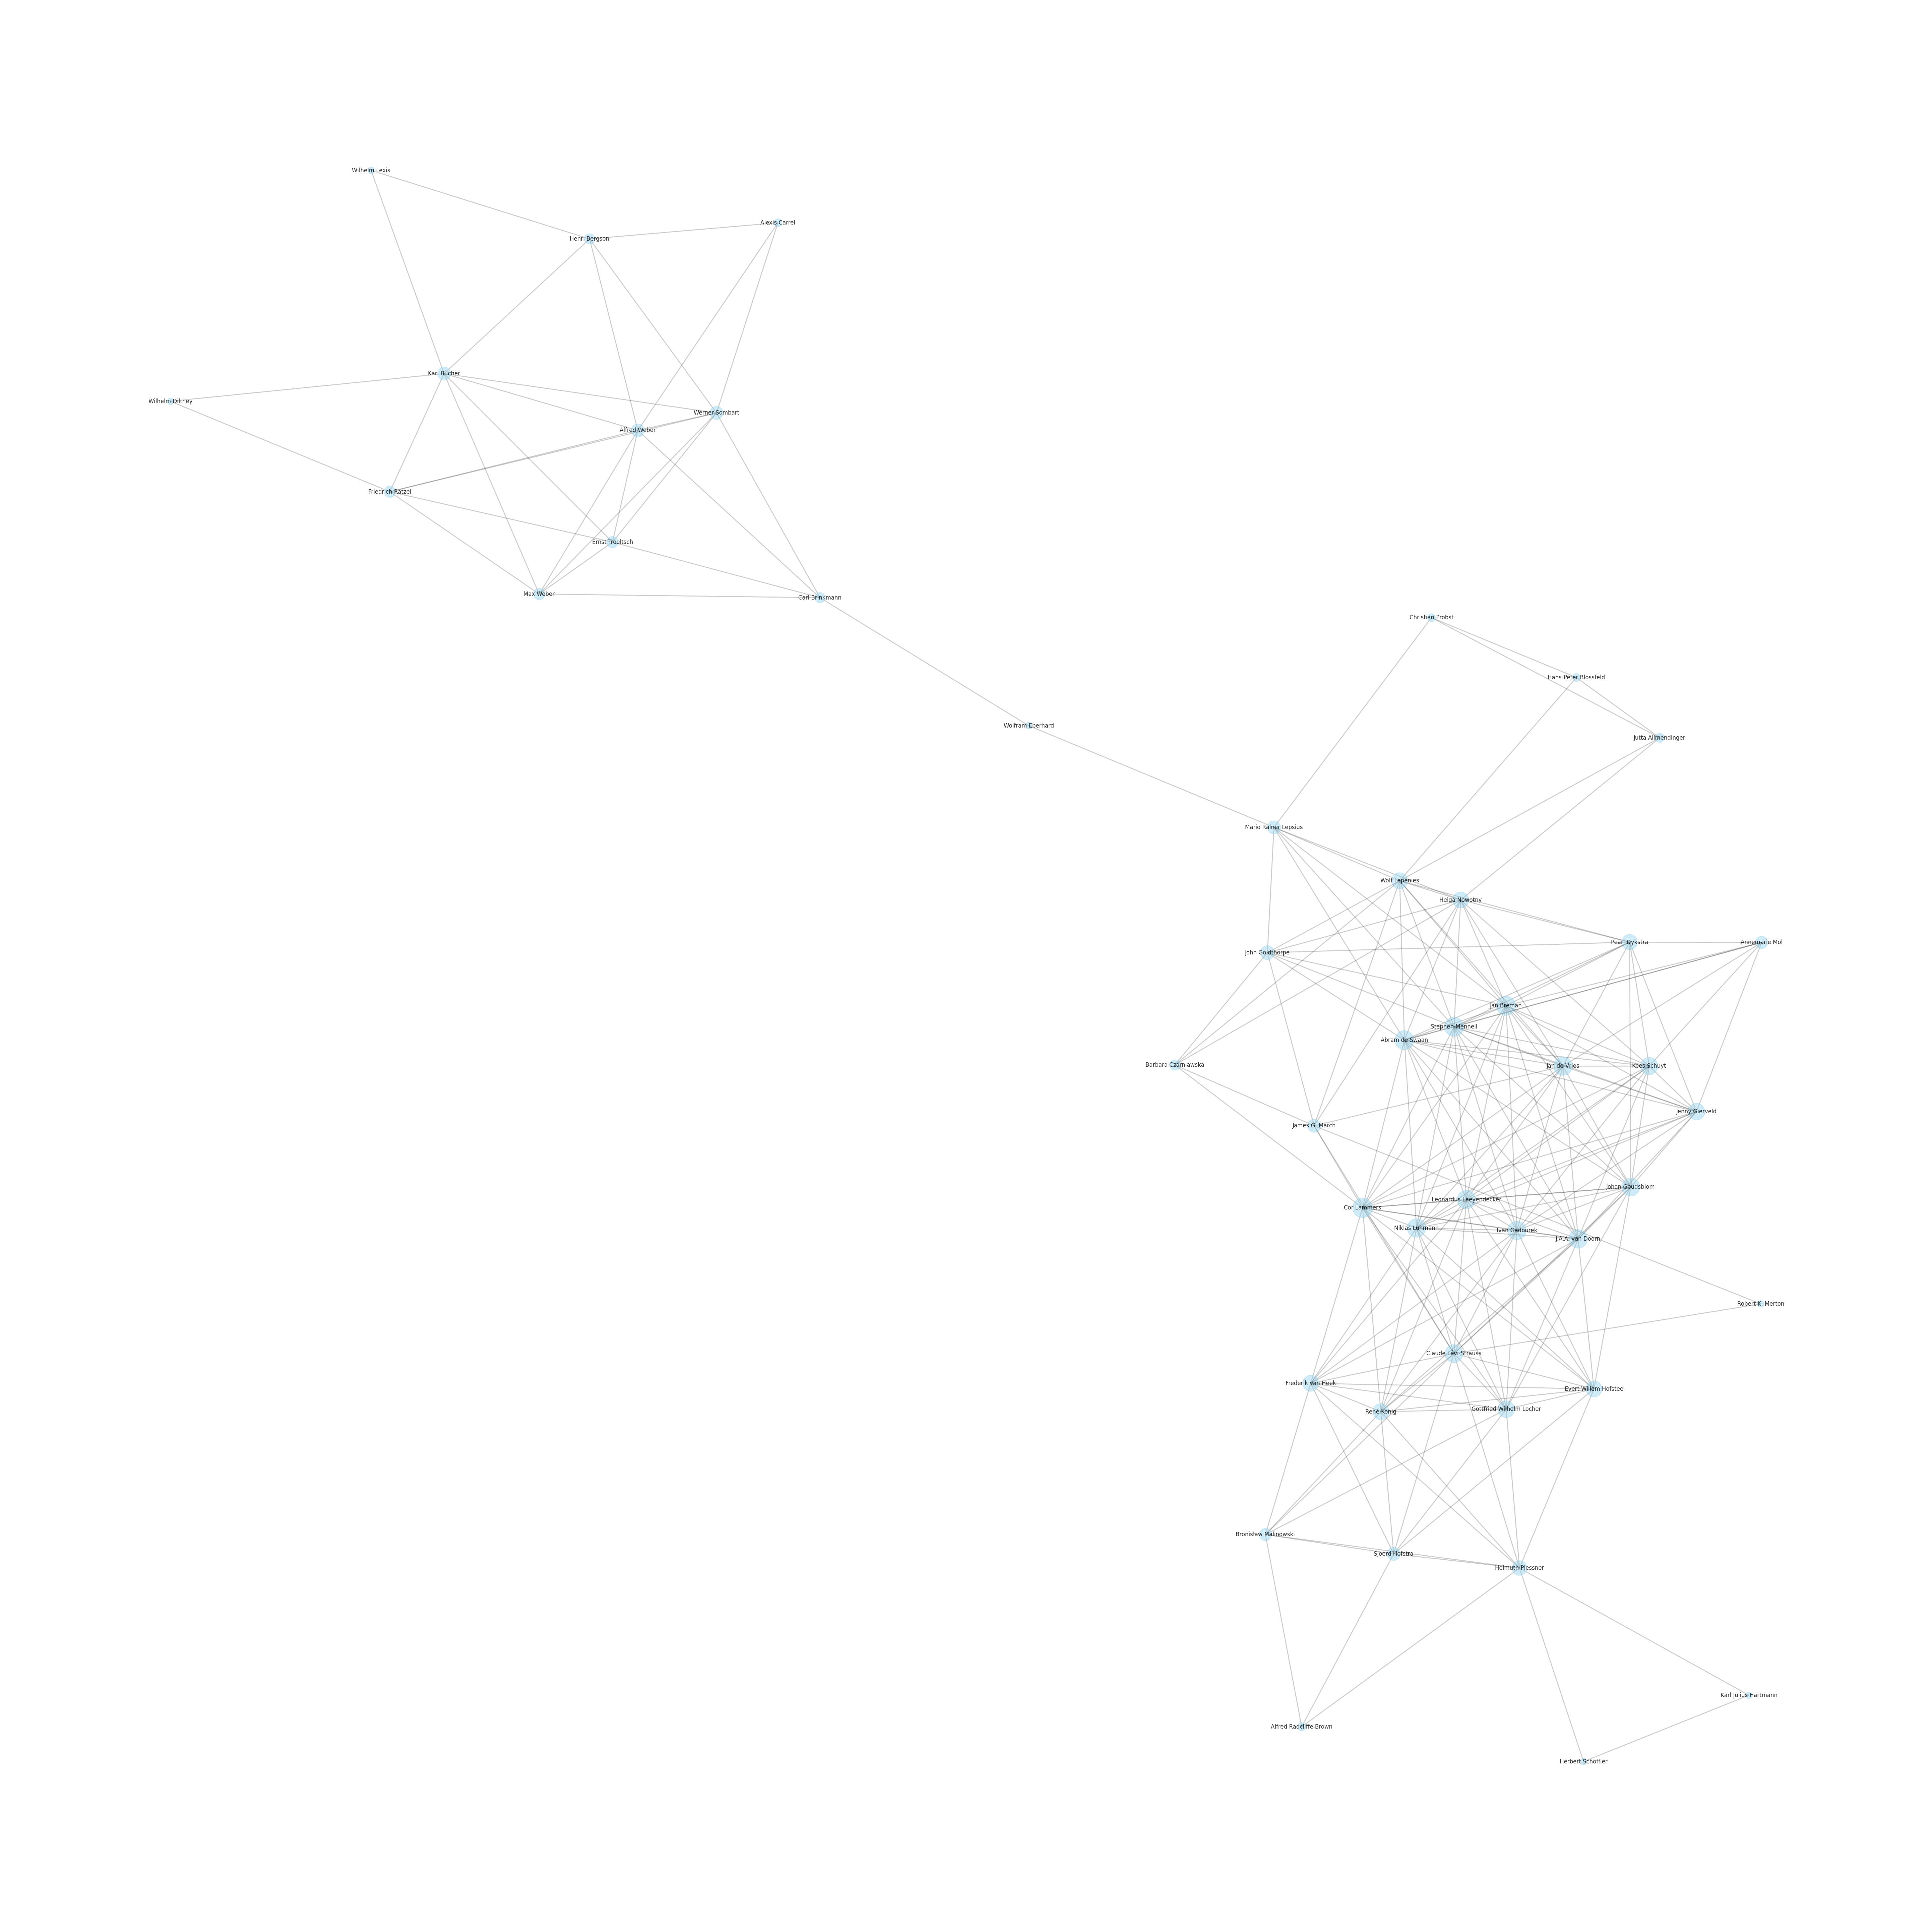

In [304]:
### 



# print(list(g.nodes.data())[:3])
# print(list(g.edges.data())[:3])

n_size = np.log(np.sqrt(nx.number_of_nodes(gu)))* 30 #*25

graph_layout = 'kamada_kawai'
n_k = 0.4
sc = 0.02

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. Choose your target graph
# We use sub_G to get the 47 nodes from the Academies
target_graph = sub_G 

# 2. Settings for the layout
graph_layout = 'kamada_kawai'
n_k = 0.4
sc = 0.02
n_size = np.log(np.sqrt(nx.number_of_nodes(target_graph))) * 30

# 3. Calculate the positions (Layout) based on target_graph
if graph_layout == 'fruchterman_reingold':
    pos = nx.fruchterman_reingold_layout(target_graph)
elif graph_layout == 'kamada_kawai':
    pos = nx.kamada_kawai_layout(target_graph)
elif graph_layout == 'spring_layout':
    pos = nx.spring_layout(target_graph, k=n_k, scale=sc)  
else:
    pos = nx.kamada_kawai_layout(target_graph)

# 4. Prepare the visual elements
plt.figure(figsize=(n_size, n_size))

# Node sizes based on degree (number of connections)
node_size = [target_graph.degree(n) * 100 for n in target_graph.nodes()]

# Extract labels for nodes and edges from target_graph
node_labels = {n: target_graph.nodes[n].get('label', n) for n in target_graph.nodes()}
edge_labels = {(u, v): d.get("orgsLabels", "") for u, v, d in target_graph.edges(data=True)}

# 5. Draw the components
# All functions must use (target_graph, pos)
nx.draw_networkx_nodes(target_graph, pos, node_size=node_size, alpha=0.4, node_color='skyblue')
nx.draw_networkx_edges(target_graph, pos, width=2, alpha=0.2)
nx.draw_networkx_labels(target_graph, pos, labels=node_labels, alpha=0.8, font_size=12)

# Optional: Edge labels (can make the graph very messy if there are many edges)
# nx.draw_networkx_edge_labels(target_graph, pos=pos, edge_labels=edge_labels, alpha=0.6, font_size=8)

# 6. Final adjustments
plt.tight_layout()
plt.axis('off') # Hides the x/y axis for a cleaner look
plt.show()


### Explore with Gephi online

* export the graph in the Gephi format
* explore it uploading the file into the [Gephi Web User Interface](https://lite.gephi.org)

In [305]:
import os

# 1. Define the variable name (based on your error, it's 'edu_76')
variable_name = "edu_76" 

# 2. Create the folder structure first. 
# 'exist_ok=True' prevents an error if the folder already exists.
os.makedirs("da_graphs", exist_ok=True)

# 3. Now run your export
nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

print(f"Success! You can now find {variable_name}.gexf in the da_graphs folder.")

Success! You can now find edu_76.gexf in the da_graphs folder.


### Main component

In [146]:
### 
li = [0]    
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li]

In [147]:

# Display variable

variable_name = 'edu_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 2615,
 'number_of_edges': 15841,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.004634846048852992}


In [148]:
### Graph to heavy to use Gephy online

# BEWARE : these can be very heavy graphs and shold not be committed to GitHub!!!

###nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [149]:
pprint.pprint(list(gu.nodes.data())[2:4])

[('http://www.wikidata.org/entity/Q538477',
  {'birthYear': 1938,
   'coded_country': 'Austria Hungary',
   'label': 'Iván Szelényi',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q100146726',
  {'birthYear': 1962,
   'coded_country': 'France',
   'label': 'Nicolas Bourgoin',
   'periodsActivity': '1996-2020'})]


### Centrality distributions

#### Degree centrality

In [150]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'birthYear': 1931,
   'coded_country': 'Austria Hungary',
   'degree': 2,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q51880715',
  {'birthYear': 1934,
   'coded_country': 'Central Europe',
   'degree': 3,
   'label': 'Sándor Kávássy',
   'periodsActivity': '1971-1995'})]


In [151]:
print(pd.Series([d[1] for d in nx.degree(gu)]).describe())

count    2615.000000
mean       12.115488
std        10.650767
min         1.000000
25%         4.000000
50%         9.000000
75%        18.000000
max        80.000000
dtype: float64


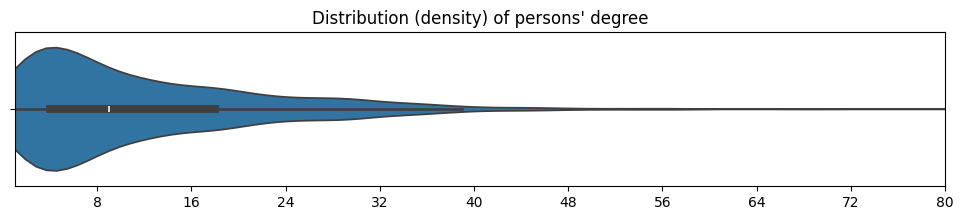

In [152]:
# Plot the distribution of degree centrality density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(12, 2))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [153]:
threshold = 50
filtered_nodes = [
    (node, data) for node, data in gu.nodes(data=True) 
    if data.get('degree', 0) > threshold
]
print(len(filtered_nodes))

19


In [154]:
pprint.pprint(filtered_nodes[:2])

[('http://www.wikidata.org/entity/Q3131629',
  {'birthYear': 1927,
   'coded_country': 'France',
   'degree': 53,
   'label': 'Henri Mendras',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1999537',
  {'birthYear': 1930,
   'coded_country': 'Baltic States Fin. Belar.',
   'degree': 58,
   'label': 'Vytautas Kavolis',
   'periodsActivity': '1971-1995'})]


In [155]:
df_filtered_nodes = pd.DataFrame([
    {'id': node, **attrs}
    for node, attrs in filtered_nodes
])

df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:10]

,id,label,birthYear,periodsActivity,coded_country,degree
5,http://www.wikidata.org/entity/Q1177958,Ferenc Miszlivetz,1954,1996-2020,Austria Hungary,80
2,http://www.wikidata.org/entity/Q553449,Thomas Sowell,1930,1971-1995,United States Can.,71
6,http://www.wikidata.org/entity/Q129948807,László Csontos,1953,1996-2020,Austria Hungary,70
16,http://www.wikidata.org/entity/Q943311,Randall Collins,1941,1971-1995,United States Can.,69
3,http://www.wikidata.org/entity/Q62274494,Catherine Paradeise,1946,1971-1995,France,67
7,http://www.wikidata.org/entity/Q28018796,Mária Neményi,1946,1971-1995,Austria Hungary,66
8,http://www.wikidata.org/entity/Q12404695,Barbara Savirski,1941,1971-1995,United States Can.,60
11,http://www.wikidata.org/entity/Q450412,Richard Sennett,1943,1971-1995,United States Can.,58
1,http://www.wikidata.org/entity/Q1999537,Vytautas Kavolis,1930,1971-1995,Baltic States Fin. Belar.,58
13,http://www.wikidata.org/entity/Q5325719,Earl Babbie,1938,1971-1995,United States Can.,57


#### Eigenvector centrality

In [156]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'birthYear': 1931,
   'coded_country': 'Austria Hungary',
   'degree': 2,
   'eigenvector': 0.001323940797563196,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q51880715',
  {'birthYear': 1934,
   'coded_country': 'Central Europe',
   'degree': 3,
   'eigenvector': 0.0021579209289978338,
   'label': 'Sándor Kávássy',
   'periodsActivity': '1971-1995'})]


In [157]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    2615.00000000000000000000
mean        0.00543722330999459134
std         0.01878778229544686082
min         0.00000000000000000012
25%         0.00000121614525204548
50%         0.00009597855085209417
75%         0.00135362410823924991
max         0.14945141046292503839
dtype: object


#### Betweenness centrality

In [158]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'betweenness': 0.0,
   'birthYear': 1931,
   'coded_country': 'Austria Hungary',
   'degree': 2,
   'eigenvector': 0.001323940797563196,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q51880715',
  {'betweenness': 0.0005482408561214599,
   'birthYear': 1934,
   'coded_country': 'Central Europe',
   'degree': 3,
   'eigenvector': 0.0021579209289978338,
   'label': 'Sándor Kávássy',
   'periodsActivity': '1971-1995'})]


In [159]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    2615.00000000000000000000
mean        0.00239755999225732454
std         0.00535638742544523958
min         0.00000000000000000000
25%         0.00000506293748763825
50%         0.00049023807064501961
75%         0.00238193647148871035
max         0.08830235629789900953
dtype: object


In [160]:
stored_graph='da_graphs/gr_edu_0.pkl'

# Save the graph to a file (compact binary format)
with open(stored_graph, 'wb') as f:
    pickle.dump(gu, f)



In [162]:
import pickle

stored_graph = 'da_graphs/gr_edu_0.pkl'

# Load the graph from the file
with open(stored_graph, 'rb') as f:
    G_loaded = pickle.load(f)

print("Graph loaded successfully!")

Graph loaded successfully!


In [186]:
### Export node attributes to dataframe correctly
nodes_data = {node: gu.nodes[node] for node in gu.nodes}
nodes_df = pd.DataFrame(nodes_data).T

# Instead of overwriting all columns, just rename the index
nodes_df.index.name = 'personUri'
nodes_df.reset_index(inplace=True)

# Now your columns will have their original, correct names!
nodes_df.head(2)


,personUri,label,birthYear,periodsActivity,coded_country,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,1931,1971-1995,Austria Hungary,2,0.001324,0.0
1,http://www.wikidata.org/entity/Q51880715,Sándor Kávássy,1934,1971-1995,Central Europe,3,0.002158,0.000548


#### Explore degree centrality on gr_edu

In [187]:
nodes_df.sort_values(by='degree', ascending=False).iloc[30:40]

,personUri,label,birthYear,periodsActivity,coded_country,degree,eigenvector,betweenness
639,http://www.wikidata.org/entity/Q1065595,Charles Murray,1943,1971-1995,United States Can.,45,0.133896,0.01141
340,http://www.wikidata.org/entity/Q112493267,Adrienne Molnár,1947,1971-1995,Austria Hungary,44,0.092322,0.000946
355,http://www.wikidata.org/entity/Q1315011,Erika Sárközy,1947,1971-1995,Austria Hungary,44,0.092322,0.000946
539,http://www.wikidata.org/entity/Q5416389,Evelyn Nakano Glenn,1950,1971-1995,United States Can.,44,0.108407,0.008359
356,http://www.wikidata.org/entity/Q1402234,Csaba Vass,1948,1971-1995,Austria Hungary,44,0.093163,0.000758
668,http://www.wikidata.org/entity/Q594320,Mark S. Granovetter,1943,1971-1995,United States Can.,44,0.132679,0.0044
359,http://www.wikidata.org/entity/Q16520695,István Illéssy,1948,1971-1995,Austria Hungary,44,0.093163,0.000757
373,http://www.wikidata.org/entity/Q96634634,András Kovács,1947,1971-1995,Austria Hungary,44,0.092322,0.000946
350,http://www.wikidata.org/entity/Q125548266,Klári László,1947,1971-1995,Austria Hungary,44,0.092322,0.000948
657,http://www.wikidata.org/entity/Q465252,Patricia Hill Collins,1948,1971-1995,United States Can.,43,0.117852,0.012623


In [188]:
nodes_df[(nodes_df.label.str.contains('Charles Murray'))|(nodes_df.label.str.contains('Csaba Vass'))|(nodes_df.label.str.contains('Sárközy'))]

,personUri,label,birthYear,periodsActivity,coded_country,degree,eigenvector,betweenness
355,http://www.wikidata.org/entity/Q1315011,Erika Sárközy,1947,1971-1995,Austria Hungary,44,0.092322,0.000946
356,http://www.wikidata.org/entity/Q1402234,Csaba Vass,1948,1971-1995,Austria Hungary,44,0.093163,0.000758
639,http://www.wikidata.org/entity/Q1065595,Charles Murray,1943,1971-1995,United States Can.,45,0.133896,0.01141


In [189]:
duckdb.query("""
    SELECT label,degree, birthYear,coded_country,periodsActivity
    FROM nodes_df
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,coded_country,periodsActivity
0,Ferenc Miszlivetz,80,1954,Austria Hungary,1996-2020
1,Thomas Sowell,71,1930,United States Can.,1971-1995
2,László Csontos,70,1953,Austria Hungary,1996-2020
3,Randall Collins,69,1941,United States Can.,1971-1995
4,Catherine Paradeise,67,1946,France,1971-1995
5,Mária Neményi,66,1946,Austria Hungary,1971-1995
6,Barbara Savirski,60,1941,United States Can.,1971-1995
7,Richard Sennett,58,1943,United States Can.,1971-1995
8,Vytautas Kavolis,58,1930,Baltic States Fin. Belar.,1971-1995
9,Earl Babbie,57,1938,United States Can.,1971-1995


In [190]:
duckdb.query("""
    SELECT label,degree, birthYear,coded_country,periodsActivity
    FROM nodes_df
    WHERE label LIKE '%Sowell%'
    ORDER BY degree DESC
    LIMIT 10
""").to_df()

,label,degree,birthYear,coded_country,periodsActivity
0,Thomas Sowell,71,1930,United States Can.,1971-1995


In [191]:
gr_edu_degree_1000=nodes_df.sort_values(by='degree', ascending=False).iloc[:1000]
#gr_edu_degree_1000.head(2)
df=gr_edu_degree_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [192]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [193]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 335.16 , dof : 56
p-value : 0.0
Inertia (Phi-square):  0.335
Cramer:  0.289


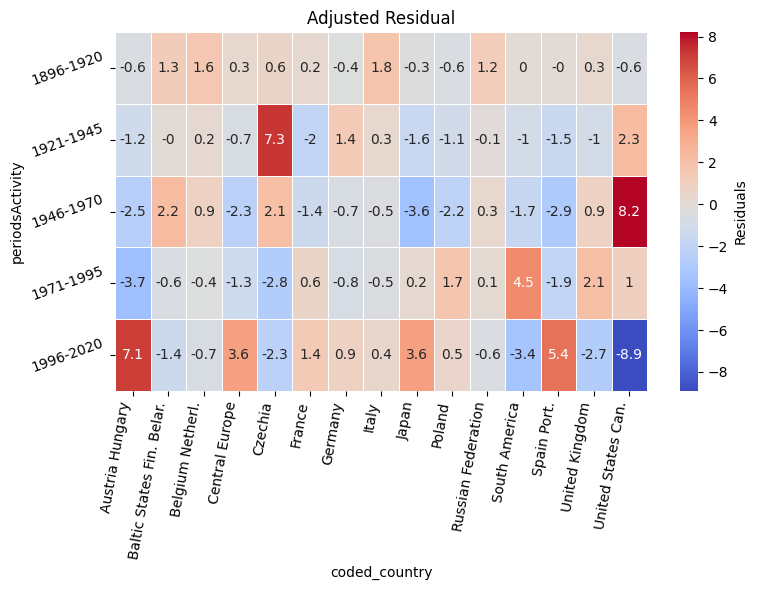

In [194]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 6))

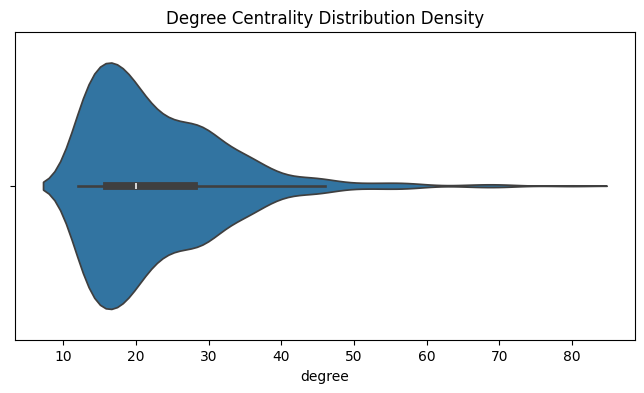

In [195]:
# Plot the distribution of degree centrality density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_degree_1000.degree, orient='h')
plt.title('Degree Centrality Distribution Density')
plt.show()

In [196]:
sg1=gr_edu_degree_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:20])


organisation_label
University of Chicago                                        106
Harvard University                                           101
Columbia University                                           82
Eötvös Loránd University                                      81
University of Tokyo                                           69
University of Warsaw                                          64
University of California, Berkeley                            56
School for Advanced Studies in the Social Sciences            52
London School of Economics and Political Science              52
Complutense University of Madrid                              44
University of Paris                                           33
Faculty of Philosophy and Sociology, University of Warsaw     32
University of Ljubljana                                       30
Goethe University Frankfurt                                   30
Freie Universität Berlin                                      28
Yale U

In [197]:
### Extract the subgraph using only the 1000 nodes
# .copy() creates a new independent graph object
sub_G = gu.subgraph(gr_edu_degree_1000.personUri.tolist()).copy()

# 4. Verify and Export
print(f"Subgraph nodes: {sub_G.number_of_nodes()}")
print(f"Subgraph edges: {sub_G.number_of_edges()}")

graph_address="da_graphs/subgraph_edu_degree_1000.graphml"

# Export directly to Gephi format
nx.write_graphml(sub_G, graph_address)

Subgraph nodes: 1000
Subgraph edges: 10118


#### Explore betweenness on gr_edu

In [198]:
nodes_df.sort_values(by='betweenness', ascending=False).iloc[:20]

,personUri,label,birthYear,periodsActivity,coded_country,degree,eigenvector,betweenness
690,http://www.wikidata.org/entity/Q60030,Herbert Marcuse,1898,1921-1945,Germany,35,0.000023,0.088302
124,http://www.wikidata.org/entity/Q62274494,Catherine Paradeise,1946,1971-1995,France,67,0.019099,0.055875
607,http://www.wikidata.org/entity/Q6381682,Kazuo Yamaguchi,1946,1971-1995,Japan,38,0.013589,0.050423
348,http://www.wikidata.org/entity/Q1177958,Ferenc Miszlivetz,1954,1996-2020,Austria Hungary,80,0.141089,0.050145
214,http://www.wikidata.org/entity/Q4723323,Alfred R. Lindesmith,1905,1946-1970,United States Can.,30,0.000207,0.049967
185,http://www.wikidata.org/entity/Q85394,René Fülöp-Miller,1891,1921-1945,Central Europe,10,0.000001,0.047878
1580,http://www.wikidata.org/entity/Q17626660,Gilbert Wheeler Beebe,1912,1946-1970,United States Can.,20,0.000561,0.042846
287,http://www.wikidata.org/entity/Q137220293,Albert J. Jovell i Fernández,1962,1996-2020,Spain Port.,18,0.00344,0.042403
1648,http://www.wikidata.org/entity/Q2590296,Wolfgang Krohn,1941,1971-1995,Germany,7,0.000048,0.041661
1990,http://www.wikidata.org/entity/Q3641717,Bolesław Tejkowski,1933,1971-1995,Poland,9,0.000119,0.041272


In [199]:
gr_edu_betweenness_1000=nodes_df.sort_values(by='betweenness', ascending=False).iloc[:1000]
#gr_edu_betweenness_1000.head(2)
df=gr_edu_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])

In [200]:
bl.check_chi_square_test_validity(crosstab)
expected=bl.bivariate_stats(crosstab)

Table valid for Chi-square test: False
Chi-square : 256.65 , dof : 70
p-value : 0.0
Inertia (Phi-square):  0.257
Cramer:  0.227


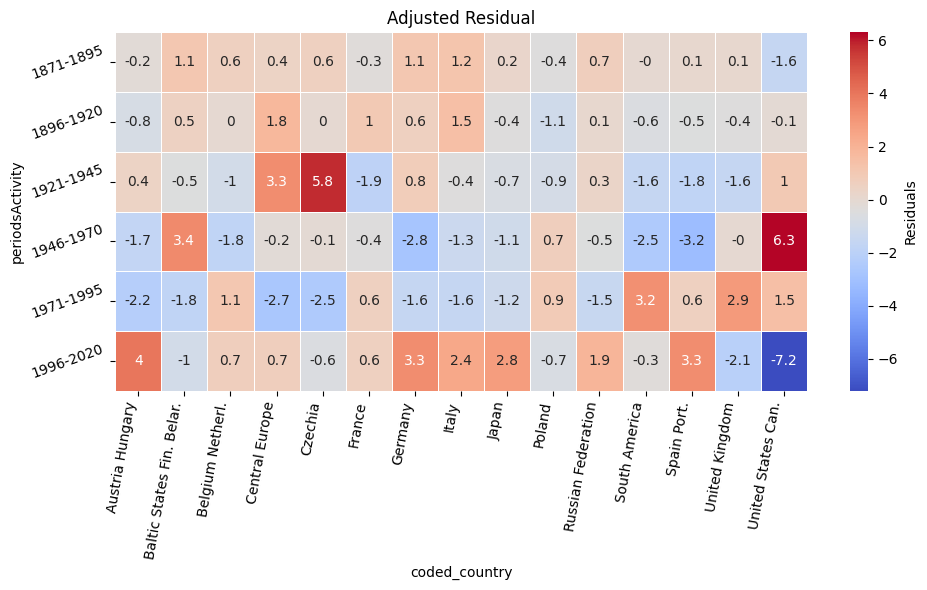

In [201]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

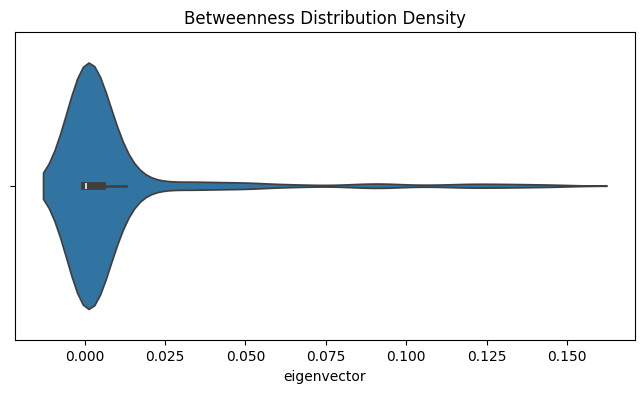

In [202]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_betweenness_1000.eigenvector, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [203]:
### Organisations where these persons studies
sg1=gr_edu_betweenness_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
University of Chicago                                 101
Harvard University                                     89
Columbia University                                    83
University of California, Berkeley                     57
University of Warsaw                                   43
London School of Economics and Political Science       40
School for Advanced Studies in the Social Sciences     38
Eötvös Loránd University                               37
University of Paris                                    36
University of Vienna                                   29
dtype: int64


#### Explore eigenvector on gr_edu

In [204]:
nodes_df.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,birthYear,periodsActivity,coded_country,degree,eigenvector,betweenness
652,http://www.wikidata.org/entity/Q2711710,Jeffrey C. Alexander,1947,1971-1995,United States Can.,56,0.149451,0.014448
680,http://www.wikidata.org/entity/Q943311,Randall Collins,1941,1971-1995,United States Can.,69,0.148774,0.023615
664,http://www.wikidata.org/entity/Q5474652,Joel Best,1946,1971-1995,United States Can.,56,0.145377,0.011441
648,http://www.wikidata.org/entity/Q1488905,Kurt W. Fischer,1943,1971-1995,United States Can.,55,0.142688,0.00669
354,http://www.wikidata.org/entity/Q129948807,László Csontos,1953,1996-2020,Austria Hungary,70,0.142682,0.02977


In [205]:
gr_edu_eigenv_1000=nodes_df.sort_values(by='eigenvector', ascending=False).iloc[:1000]
df=gr_edu_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [206]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [207]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 209.12 , dof : 28
p-value : 0.0
Inertia (Phi-square):  0.209
Cramer:  0.323


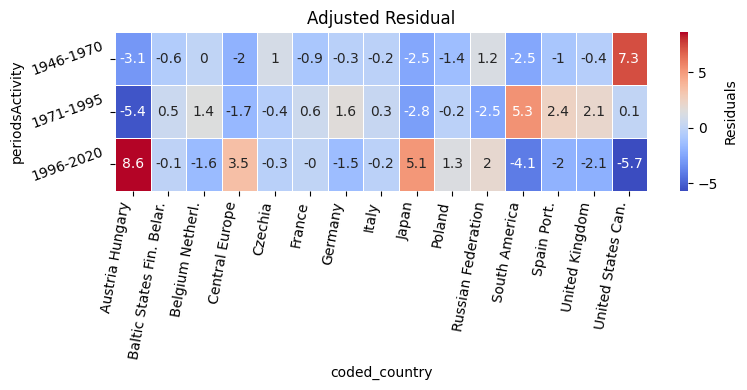

In [208]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 4))

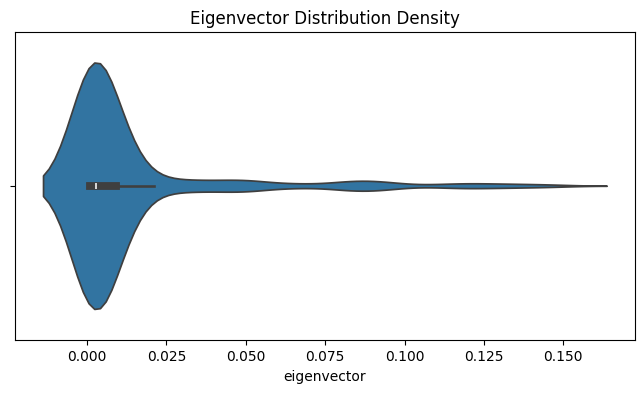

In [209]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_edu_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [210]:
sg1=gr_edu_eigenv_1000.merge(df_po[df_po['relationship']=='education'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
Harvard University                                    90
Eötvös Loránd University                              86
University of Chicago                                 84
Columbia University                                   64
University of California, Berkeley                    61
University of Warsaw                                  54
London School of Economics and Political Science      44
School for Advanced Studies in the Social Sciences    42
University of Tokyo                                   38
University of Paris                                   33
dtype: int64


In [211]:
l_nodes=[n for n in gr_edu_eigenv_1000[:100].personUri]
print(l_nodes[:2])

['http://www.wikidata.org/entity/Q2711710', 'http://www.wikidata.org/entity/Q943311']


In [212]:
### Extract an egograph of the first 100 more central individual (eigenvalue centrality)

# 3. Extract ego networks
# radius=1 includes immediate neighbors; radius=2 includes neighbors of neighbors
ego_networks = [nx.ego_graph(gu, n, radius=1) for n in l_nodes]

# 4. Combine into a single subgraph
combined_ego_graph = nx.compose_all(ego_networks)

# 5. Export to GraphML for Gephi
graph_address='da_graphs/ego_ntwk_eingenvalue_100_edu.graphml'
nx.write_graphml(combined_ego_graph, graph_address)

## Explore the employment relationships graph

### Employment

In [213]:
print(len(gr_empl))

40859


In [214]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_empl.to_dict(orient='records')]
print(len(l))

40859


In [215]:
## Créate the empty graph
G_empl=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_empl.add_edges_from(l)

naf.basic_graph_properties(G_empl)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3570,
 'number_of_edges': 40859,
 '------': '------',
 'is connected': False,
 'components': 93,
 'density': 0.00641361616095023}


#### Add metadata to nodes

In [216]:
df_pm = df_p[['person_uri','labelPer','periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label','periodsActivity','coded_country']
df_pm.head()


,uri,label,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1846-1870,United States Can.
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1846-1870,France
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1846-1870,France
3,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1846-1870,United Kingdom
4,http://www.wikidata.org/entity/Q358497,Alexei Khomyakov,1846-1870,Russian Federation


In [217]:
df_p.columns

Index(['person_uri', 'labelPer', 'gender', 'birthYear', 'coded_country',
       'periodsActivity'],
      dtype='object')

In [218]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])

In [219]:

## Add attributes
nx.set_node_attributes(G_empl, ln)
pprint.pprint(list(G_empl.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000087',
  {'coded_country': 'Czechia',
   'label': 'Horst Baier',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1039705',
  {'coded_country': 'Germany',
   'label': 'Carl Mayer',
   'periodsActivity': '1946-1970'})]


#### Components

In [220]:
### Create a list of graphs, one per component
perS = [G_empl.subgraph(c).copy() for c in nx.connected_components(G_empl)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 3267], [20, 29], [17, 10], [26, 10], [43, 10]]


#### Main component

In [221]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [222]:

# Display variable

variable_name = 'empl_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 3267,
 'number_of_edges': 40340,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.007561371476085054}


In [223]:
### Graph to heavy to use Gephy online
# nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [224]:
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000087',
  {'coded_country': 'Czechia',
   'label': 'Horst Baier',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1039705',
  {'coded_country': 'Germany',
   'label': 'Carl Mayer',
   'periodsActivity': '1946-1970'})]


### Centrality distributions

#### Degree centrality

In [225]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000087',
  {'coded_country': 'Czechia',
   'degree': 49,
   'label': 'Horst Baier',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1039705',
  {'coded_country': 'Germany',
   'degree': 38,
   'label': 'Carl Mayer',
   'periodsActivity': '1946-1970'})]


In [226]:
### Degree centrality distribution
print(pd.Series([d[1] for d in nx.degree(gu)]).describe())

count    3267.000000
mean       24.695439
std        27.204258
min         1.000000
25%         6.000000
50%        16.000000
75%        32.000000
max       273.000000
dtype: float64


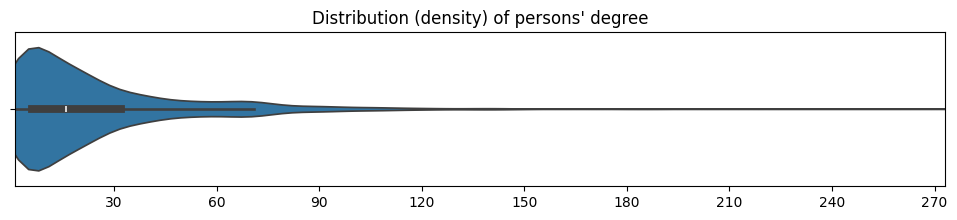

In [227]:
# Plot the distribution of eigenvector density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(12, 2))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [228]:
threshold = 100
filtered_nodes = [
    (node, data) for node, data in gu.nodes(data=True) 
    if data.get('degree', 0) > threshold
]

In [229]:
print(len(filtered_nodes))

75


In [230]:
pprint.pprint(filtered_nodes[:2])

[('http://www.wikidata.org/entity/Q1589285',
  {'coded_country': 'Germany',
   'degree': 156,
   'label': 'Hauke Brunkhorst',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1714580',
  {'coded_country': 'Germany',
   'degree': 107,
   'label': 'Jutta Allmendinger',
   'periodsActivity': '1996-2020'})]


In [231]:
df_filtered_nodes = pd.DataFrame([
    {'id': node, **attrs}
    for node, attrs in filtered_nodes
])

df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:20]

,id,label,periodsActivity,coded_country,degree
17,http://www.wikidata.org/entity/Q313852,Tzvetan Todorov,1971-1995,Central Europe,273
62,http://www.wikidata.org/entity/Q231349,Mary Douglas,1946-1970,Italy,209
50,http://www.wikidata.org/entity/Q717635,Charles Tilly,1971-1995,United States Can.,197
11,http://www.wikidata.org/entity/Q650151,Jacob Taubes,1946-1970,Austria Hungary,191
47,http://www.wikidata.org/entity/Q6662676,Lloyd Ohlin,1946-1970,United States Can.,188
29,http://www.wikidata.org/entity/Q310161,Manuel Castells,1971-1995,Spain Port.,186
35,http://www.wikidata.org/entity/Q1586301,Harrison White,1971-1995,United States Can.,184
49,http://www.wikidata.org/entity/Q6969175,Nathan Keyfitz,1946-1970,United States Can.,179
13,http://www.wikidata.org/entity/Q797638,Baber Johansen,1971-1995,Germany,178
28,http://www.wikidata.org/entity/Q264341,Ruth Cardoso,1971-1995,South America,171


In [232]:
sg_edu_degree=df_filtered_nodes.sort_values(by='degree', ascending=False).iloc[:20]\
    .merge(df_po[df_po['relationship']=='employment'],
                        left_on='id',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:20])


organisation_label
Harvard University                                           90
Eötvös Loránd University                                     86
University of Chicago                                        84
Columbia University                                          64
University of California, Berkeley                           61
University of Warsaw                                         54
London School of Economics and Political Science             44
School for Advanced Studies in the Social Sciences           42
University of Tokyo                                          38
University of Paris                                          33
Corvinus University of Budapest                              29
Faculty of Philosophy and Sociology, University of Warsaw    28
Yale University                                              26
University of Michigan                                       26
Goethe University Frankfurt                                  26
University of Wiscons

In [233]:
gr_empl.head()

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1039705,Goethe University Frankfurt,1,http://www.wikidata.org/entity/Q50662,1971-1995,1946-1970
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1078177,Goethe University Frankfurt,1,http://www.wikidata.org/entity/Q50662,1971-1995,1971-1995
2,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q1081982,Goethe University Frankfurt,1,http://www.wikidata.org/entity/Q50662,1971-1995,1996-2020
3,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q109032,Goethe University Frankfurt,1,http://www.wikidata.org/entity/Q50662,1971-1995,1971-1995
4,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q124333,Goethe University Frankfurt,1,http://www.wikidata.org/entity/Q50662,1971-1995,1946-1970


#### Eigenvector centrality

In [234]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000087',
  {'coded_country': 'Czechia',
   'degree': 49,
   'eigenvector': 0.004334398136764967,
   'label': 'Horst Baier',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1039705',
  {'coded_country': 'Germany',
   'degree': 38,
   'eigenvector': 0.0031409287007157583,
   'label': 'Carl Mayer',
   'periodsActivity': '1946-1970'})]


In [235]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    3267.00000000000000000000
mean        0.00633000057520006262
std         0.01631268708469977083
min         0.00000000000004051433
25%         0.00004696318245100945
50%         0.00054275715353704847
75%         0.00286447472692833056
max         0.15126944483830781496
dtype: object


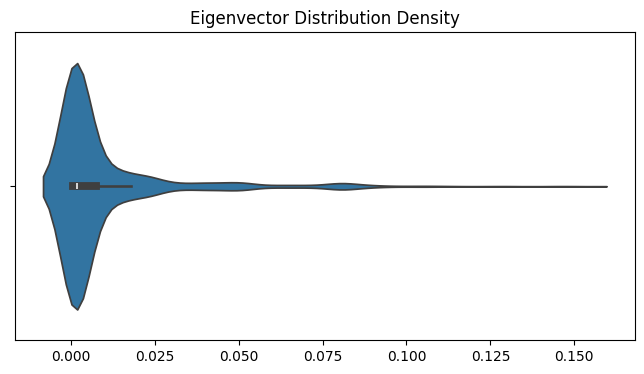

In [236]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

#### Betweenness centrality

In [237]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000087',
  {'betweenness': 6.621913323476023e-05,
   'coded_country': 'Czechia',
   'degree': 49,
   'eigenvector': 0.004334398136764967,
   'label': 'Horst Baier',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q1039705',
  {'betweenness': 8.559547527780161e-05,
   'coded_country': 'Germany',
   'degree': 38,
   'eigenvector': 0.0031409287007157583,
   'label': 'Carl Mayer',
   'periodsActivity': '1946-1970'})]


In [238]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    3267.00000000000000000000
mean        0.00100050983931113590
std         0.00379568721548032657
min         0.00000000000000000000
25%         0.00000000000000000000
50%         0.00002378854991676321
75%         0.00046395856152654075
max         0.07272835683029697795
dtype: object


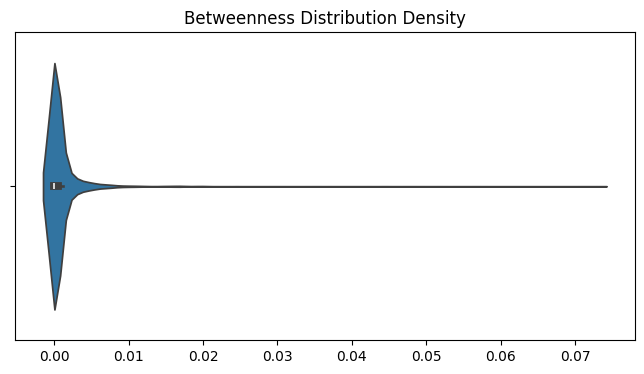

In [239]:
# Plot the distribution of eigenbetweenness vector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness_s, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [240]:
### Export node attributes to dataframe
nodes_data ={node: gu.nodes[node] for node in gu.nodes}
nodes_df_empl = pd.DataFrame(nodes_data).T
nodes_df_empl.reset_index(inplace=True)
nodes_df_empl.columns = ['personUri', 'label','periodsActivity', 'coded_country','degree','eigenvector', 'betweenness']
nodes_df_empl.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000087,Horst Baier,1971-1995,Czechia,49,0.004334,0.000066
1,http://www.wikidata.org/entity/Q1039705,Carl Mayer,1946-1970,Germany,38,0.003141,0.000086


#### Explore eigenvector on gr_empl

In [241]:
nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
165,http://www.wikidata.org/entity/Q313852,Tzvetan Todorov,1971-1995,Central Europe,273,0.151269,0.050151
506,http://www.wikidata.org/entity/Q6662676,Lloyd Ohlin,1946-1970,United States Can.,188,0.145847,0.006078
466,http://www.wikidata.org/entity/Q1586301,Harrison White,1971-1995,United States Can.,184,0.144271,0.006269
511,http://www.wikidata.org/entity/Q717635,Charles Tilly,1971-1995,United States Can.,197,0.130187,0.038322
124,http://www.wikidata.org/entity/Q650151,Jacob Taubes,1946-1970,Austria Hungary,191,0.129329,0.01994


In [242]:
gr_empl_eigenv_1000=nodes_df_empl.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_empl_eigenv_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
165,http://www.wikidata.org/entity/Q313852,Tzvetan Todorov,1971-1995,Central Europe,273,0.151269,0.050151
506,http://www.wikidata.org/entity/Q6662676,Lloyd Ohlin,1946-1970,United States Can.,188,0.145847,0.006078


In [243]:
df=gr_empl_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [244]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [245]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 113.16 , dof : 70
p-value : 0.001
Inertia (Phi-square):  0.113
Cramer:  0.15


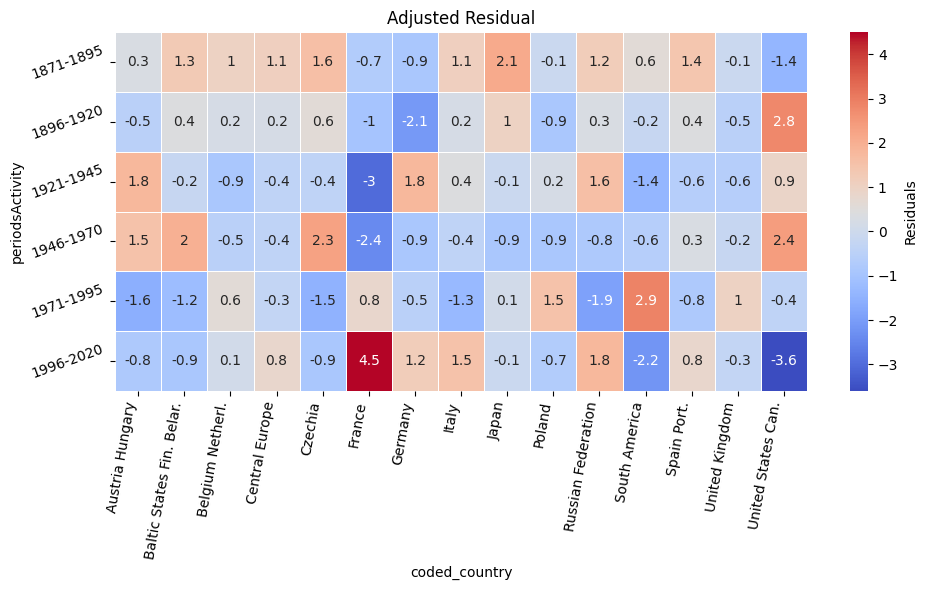

In [246]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

In [247]:
crosstab

periodsActivity,1871-1895,1896-1920,1921-1945,1946-1970,1971-1995,1996-2020
coded_country,,,,,,
Austria Hungary,0,0,7,13,14,5
Baltic States Fin. Belar.,0,0,1,6,4,1
Belgium Netherl.,0,0,0,3,9,3
Central Europe,0,0,1,3,7,4
Czechia,0,0,0,5,2,0
France,0,2,5,25,80,48
Germany,0,0,24,38,84,38
Italy,0,0,2,3,5,5
Japan,0,0,0,0,3,1


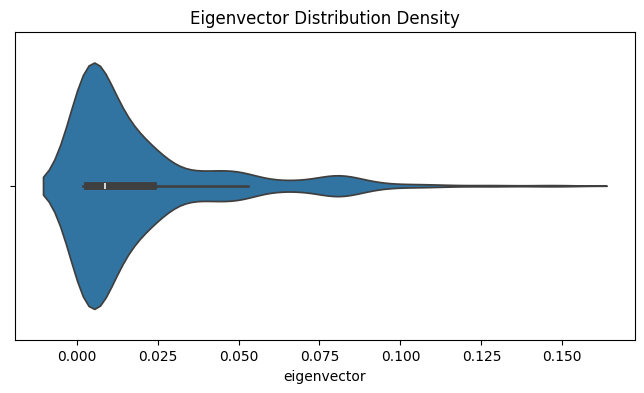

In [248]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_empl_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [249]:
sg2=gr_empl_eigenv_1000.merge(df_po[df_po['relationship']=='employment'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg2.sort_values(ascending=False)[:20])


organisation_label
Harvard University                                    86
University of Chicago                                 84
Columbia University                                   81
National Center for Scientific Research               73
Freie Universität Berlin                              61
Goethe University Frankfurt                           60
University of Warsaw                                  53
School for Advanced Studies in the Social Sciences    51
University of California, Berkeley                    50
London School of Economics and Political Science      47
University of Michigan                                42
University of California, Los Angeles                 42
Stanford University                                   35
Yale University                                       35
New York University                                   29
University of Paris                                   29
Sciences Po                                           25
University o

#### Explore betweenness on gr_empl

In [250]:
nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
301,http://www.wikidata.org/entity/Q85738,Emil Lederer,1921-1945,Czechia,39,0.000867,0.072728
743,http://www.wikidata.org/entity/Q11522129,Yoshio Sugimoto,1971-1995,Japan,13,0.000045,0.055953
2146,http://www.wikidata.org/entity/Q235125,Ágnes Heller,1971-1995,Austria Hungary,13,0.003611,0.055818
165,http://www.wikidata.org/entity/Q313852,Tzvetan Todorov,1971-1995,Central Europe,273,0.151269,0.050151
1950,http://www.wikidata.org/entity/Q11570556,Tatsumi Makino,1946-1970,Japan,24,0.000011,0.045915


In [251]:
gr_empl_betweenness_1000=nodes_df_empl.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_empl_betweenness_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
301,http://www.wikidata.org/entity/Q85738,Emil Lederer,1921-1945,Czechia,39,0.000867,0.072728
743,http://www.wikidata.org/entity/Q11522129,Yoshio Sugimoto,1971-1995,Japan,13,0.000045,0.055953


In [252]:
df=gr_empl_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [253]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [254]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 150.25 , dof : 84
p-value : 0.0
Inertia (Phi-square):  0.15
Cramer:  0.158


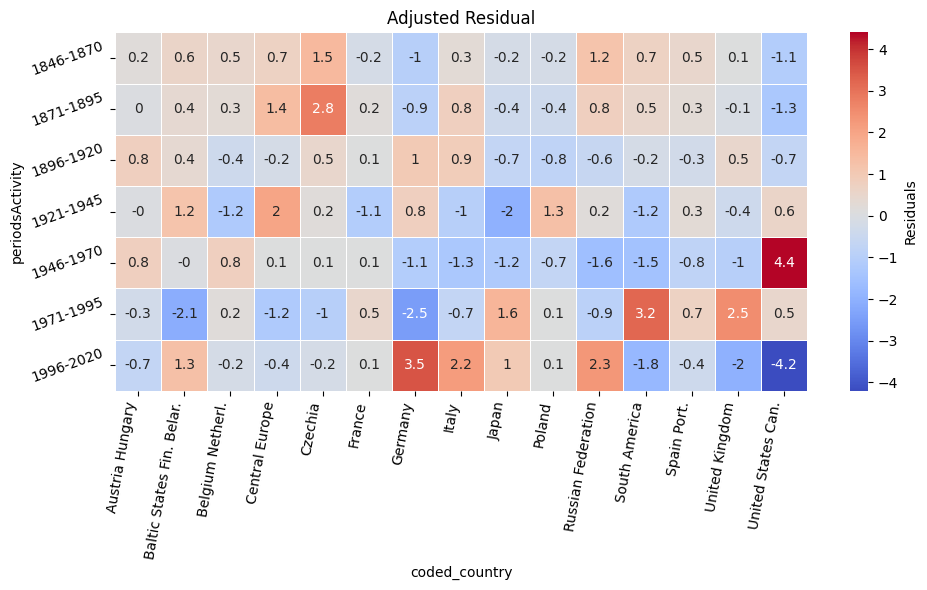

In [255]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

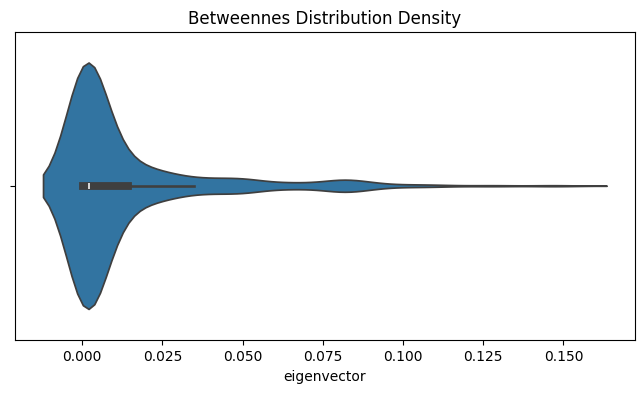

In [256]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_empl_betweenness_1000.eigenvector, orient='h')
plt.title('Betweennes Distribution Density')
plt.show()

In [257]:
sg2=gr_empl_betweenness_1000.merge(df_po[df_po['relationship']=='employment'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg2.sort_values(ascending=False)[:20])


organisation_label
Harvard University                                    63
Columbia University                                   59
University of Chicago                                 55
Humboldt-Universität zu Berlin                        40
London School of Economics and Political Science      39
Freie Universität Berlin                              34
University of Warsaw                                  33
National Center for Scientific Research               33
School for Advanced Studies in the Social Sciences    32
University of Michigan                                28
Yale University                                       28
University of California, Berkeley                    28
University of Vienna                                  28
Stanford University                                   26
University of California, Los Angeles                 25
University of Cologne                                 24
Goethe University Frankfurt                           22
University o

In [258]:
l_nodes=[n for n in gr_empl_betweenness_1000[:30].personUri]
print(l_nodes[:2])

['http://www.wikidata.org/entity/Q85738', 'http://www.wikidata.org/entity/Q11522129']


In [259]:
### Extract an egograph of the first 100 more central individual (eigenvalue centrality)

# Extract ego networks
# radius=1 includes immediate neighbors; radius=2 includes neighbors of neighbors
ego_networks = [nx.ego_graph(gu, n, radius=1) for n in l_nodes]

# Combine into a single subgraph
combined_ego_graph = nx.compose_all(ego_networks)

# 5. Export to GraphML for Gephi
graph_address='da_graphs/ego_ntwk_betweennes_100_empl_radius_1.graphml'
nx.write_graphml(combined_ego_graph, graph_address)

## Explore the membership relationships graph

In [260]:
gr_memb.head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,periodsActivity_x,periodsActivity_y
0,http://www.wikidata.org/entity/Q1000622,http://www.wikidata.org/entity/Q108198189,Academia Europaea,1,http://www.wikidata.org/entity/Q337234,1971-1995,1971-1995
1,http://www.wikidata.org/entity/Q1000622,http://www.wikidata.org/entity/Q1096729,Hungarian Academy of Sciences,1,http://www.wikidata.org/entity/Q265058,1971-1995,1946-1970


In [261]:
## Provide the data in the format 
# required by Networkx

l = [tuple(
    (e['person_uri_x'], e['person_uri_y'],
     {'orgsUris':e['orgs_uris'], 'orgsLabels':e['orgs_labels'], 'orgsNumber':e['orgs_number'],   
      'periods_x':e['periodsActivity_x'], 'periods_y':e['periodsActivity_y']}
     )) 
     for e in gr_memb.to_dict(orient='records')]
print(len(l))

16222


In [262]:
## Créate the empty graph
G_memb=nx.Graph()

## Add relationships to graph
# Multiple rows between two edges are taken only once
G_memb.add_edges_from(l)

naf.basic_graph_properties(G_memb)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 903,
 'number_of_edges': 16222,
 '------': '------',
 'is connected': False,
 'components': 40,
 'density': 0.03983273296943178}


#### Add metadata to nodes

In [263]:
df_pm = df_p[['person_uri','labelPer','periodsActivity','coded_country']]
df_pm = df_pm.drop_duplicates()
df_pm.columns=['uri', 'label','periodsActivity','coded_country']
df_pm.head()


,uri,label,periodsActivity,coded_country
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1846-1870,United States Can.
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1846-1870,France
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1846-1870,France
3,http://www.wikidata.org/entity/Q234570,Harriet Martineau,1846-1870,United Kingdom
4,http://www.wikidata.org/entity/Q358497,Alexei Khomyakov,1846-1870,Russian Federation


In [264]:
### Prepare data to add to nodes
# The data must be of type : dictionary, i.e. key:value structure
ln = dict([(e['uri'],
     {'label':e['label'], 'periodsActivity':e['periodsActivity'],
      'coded_country':e['coded_country']}
     ) for e in df_pm.to_dict(orient='records')])
# print(str(l)[:200])

In [265]:

## Add attributes
nx.set_node_attributes(G_memb, ln)
pprint.pprint(list(G_memb.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000622',
  {'coded_country': 'Austria Hungary',
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q108198189',
  {'coded_country': 'Poland',
   'label': 'Witold Morawski',
   'periodsActivity': '1971-1995'})]


#### Components

In [266]:
### Create a list of graphs, one per component
perS = [G_memb.subgraph(c).copy() for c in nx.connected_components(G_memb)]

### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
ln = sorted([[i,len(s.nodes)] for i,s in enumerate(perS)], key = lambda row: row[1], reverse=True)
print(ln[:5])

### Again we observe that there is a big connected graphe 
# and a multitude of small graphs

[[0, 800], [4, 5], [14, 5], [2, 4], [5, 4]]


#### Main component

In [267]:
### 
li = [0]    # [15, 33, 30]
ll = [list(perS[i[0]].nodes.data()) for i in ln if i[0] in li ]
#pprint.pprint(str(ll)[:300])

In [268]:

# Display variable

variable_name = 'memb_0'

globals()[variable_name] = nx.Graph()

gu=globals()[variable_name]

for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    gu = nx.union(gu, perS[i])
naf.basic_graph_properties(gu)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 800,
 'number_of_edges': 16139,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.050497496871088864}


In [269]:
### Graph to heavy to use Gephy online
# nx.write_gexf(gu, f"da_graphs/{variable_name}.gexf")

In [270]:
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'coded_country': 'Austria Hungary',
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q108198189',
  {'coded_country': 'Poland',
   'label': 'Witold Morawski',
   'periodsActivity': '1971-1995'})]


In [271]:
### Add degree centrality to nodes
degree = dict([(d[0], {'degree': d[1]}) for d in nx.degree(gu)])
nx.set_node_attributes(gu, degree)
pprint.pprint(list(gu.nodes.data())[:2])


[('http://www.wikidata.org/entity/Q1000622',
  {'coded_country': 'Austria Hungary',
   'degree': 77,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q108198189',
  {'coded_country': 'Poland',
   'degree': 73,
   'label': 'Witold Morawski',
   'periodsActivity': '1971-1995'})]


### Degree distribution

count    800.000000
mean      40.347500
std       49.855604
min        1.000000
25%        6.000000
50%       16.000000
75%       62.250000
max      220.000000
dtype: float64


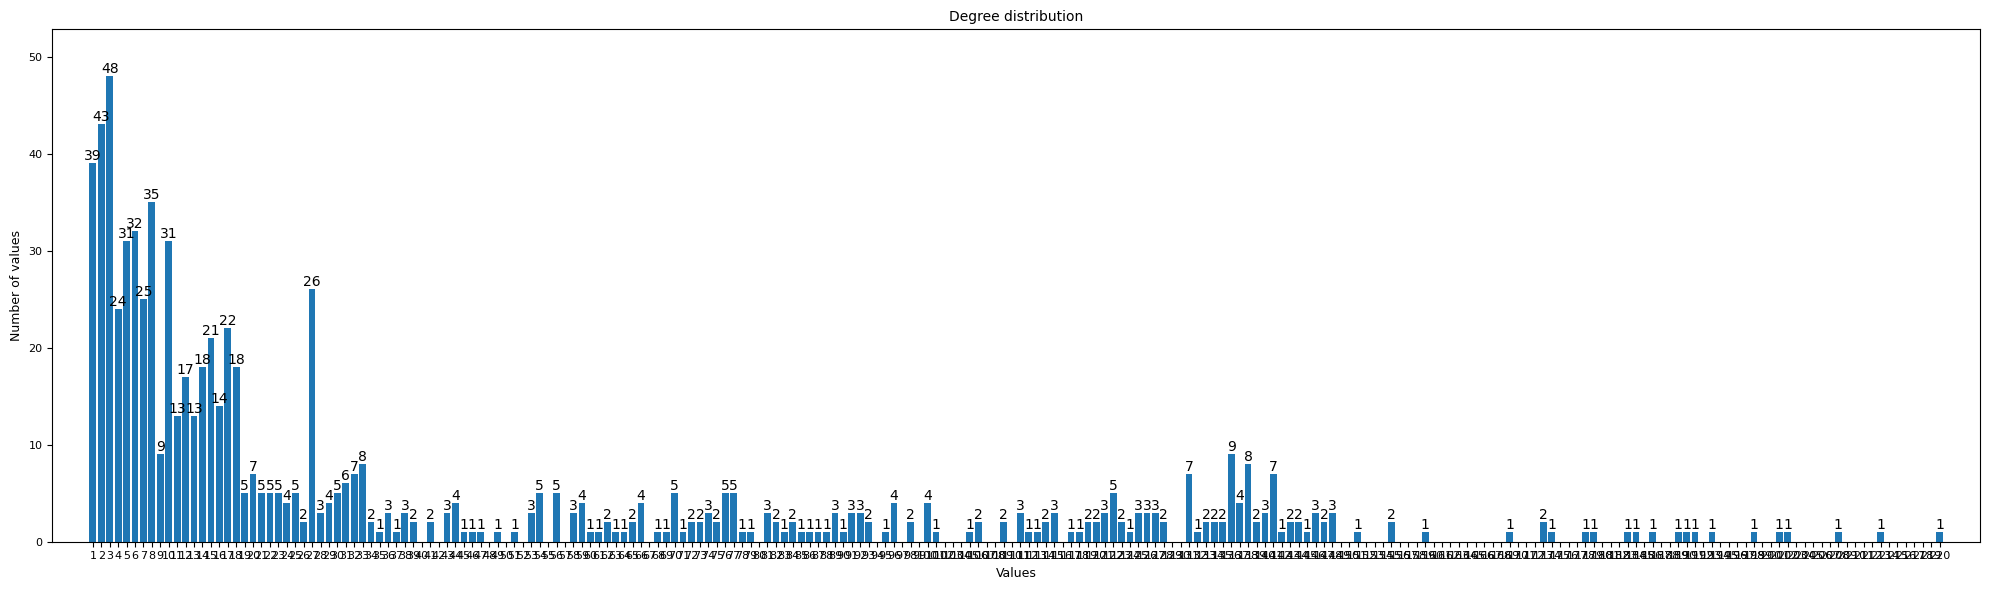

In [272]:
### Plot degree distribution
d = [d[1] for d in nx.degree(gu)]
naf.describe_plot_integers_distribution(d,'Degree distribution')

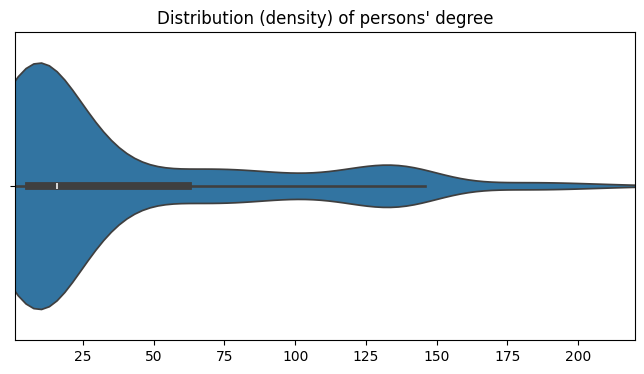

In [273]:
# Plot the distribution of de density

degree=[d[1] for d in nx.degree(gu)]

min_val = min(degree)
max_val = max(degree)

plt.figure(figsize=(8,4))
ax = sns.violinplot(data=degree, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of persons\' degree')
plt.show()

In [274]:
### Add eigenvector to nodes

## If error: PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
# increase number of max iterations
eigenvector = nx.eigenvector_centrality(gu, max_iter=200)
nx.set_node_attributes(gu, eigenvector, 'eigenvector')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'coded_country': 'Austria Hungary',
   'degree': 77,
   'eigenvector': 0.020846128158307397,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q108198189',
  {'coded_country': 'Poland',
   'degree': 73,
   'eigenvector': 0.02146148722922933,
   'label': 'Witold Morawski',
   'periodsActivity': '1971-1995'})]


In [275]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series(list(eigenvector.values()))
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    800.00000000000000000000
mean       0.01781856236649777270
std        0.03055594733580051583
min        0.00000000000036106209
25%        0.00005485341982806694
50%        0.00165158689208449398
75%        0.01989720184053118263
max        0.09909522217276119094
dtype: object


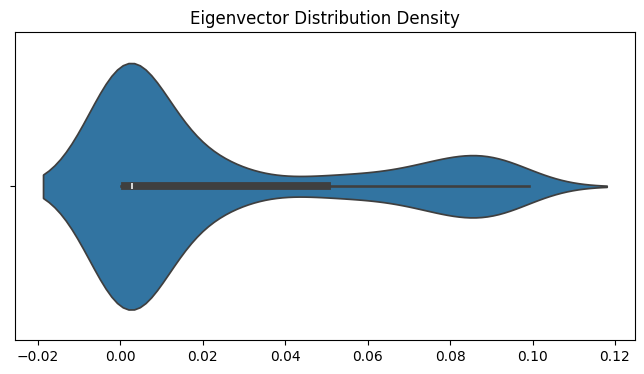

In [276]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=eigenvector_s[eigenvector_s> 0.00013610493515402787], orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [277]:
### Add betweenness to nodes
# Parameters for approximation: k=500, seed=42 and speed up

betweenness = nx.betweenness_centrality(gu, k=500, seed=42)
nx.set_node_attributes(gu, betweenness, 'betweenness')
pprint.pprint(list(gu.nodes.data())[:2])

[('http://www.wikidata.org/entity/Q1000622',
  {'betweenness': 0.009304336660140973,
   'coded_country': 'Austria Hungary',
   'degree': 77,
   'eigenvector': 0.020846128158307397,
   'label': 'Zsuzsa Ferge',
   'periodsActivity': '1971-1995'}),
 ('http://www.wikidata.org/entity/Q108198189',
  {'betweenness': 0.0002573254153216739,
   'coded_country': 'Poland',
   'degree': 73,
   'eigenvector': 0.02146148722922933,
   'label': 'Witold Morawski',
   'periodsActivity': '1971-1995'})]


In [278]:
### Plot betweenness density distribution 
betweenness_s = pd.Series(list(betweenness.values()))
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    800.00000000000000000000
mean       0.00316267259523670026
std        0.00805035925026757748
min        0.00000000000000000000
25%        0.00000000000000000000
50%        0.00026259683923306556
75%        0.00287267330663333034
max        0.08336702415637121943
dtype: object


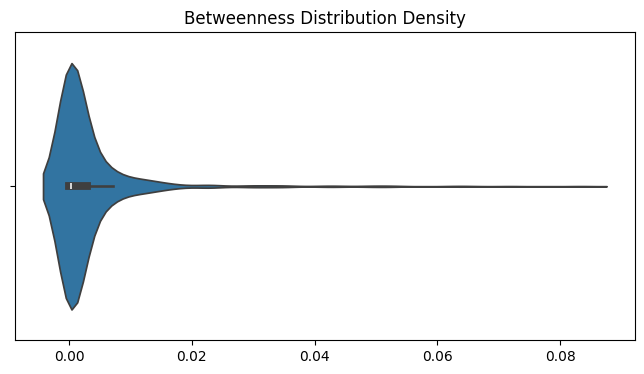

In [279]:
# Plot the distribution of eigenbetweenness vector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=betweenness_s, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [280]:
### Export node attributes to dataframe
nodes_data ={node: gu.nodes[node] for node in gu.nodes}
nodes_df_memb = pd.DataFrame(nodes_data).T
nodes_df_memb.reset_index(inplace=True)
nodes_df_memb.columns = ['personUri', 'label', 
                         'periodsActivity', 'coded_country',
                         'degree','eigenvector', 'betweenness']
nodes_df_memb.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
0,http://www.wikidata.org/entity/Q1000622,Zsuzsa Ferge,1971-1995,Austria Hungary,77,0.020846,0.009304
1,http://www.wikidata.org/entity/Q108198189,Witold Morawski,1971-1995,Poland,73,0.021461,0.000257


#### Explore eigenvector on gr_memb

In [281]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
57,http://www.wikidata.org/entity/Q62478,Juan José Linz,1971-1995,Germany,191,0.099095,0.011367
68,http://www.wikidata.org/entity/Q7365159,Ronald P. Dore,1946-1970,United Kingdom,190,0.098777,0.015973
42,http://www.wikidata.org/entity/Q333686,Alain Touraine,1946-1970,France,202,0.098724,0.043668
69,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,1971-1995,Germany,220,0.098532,0.083367
75,http://www.wikidata.org/entity/Q9382864,Włodzimierz Wesołowski,1971-1995,Poland,208,0.097706,0.05284


In [282]:
gr_memb_eigenv_1000=nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:1000]
gr_memb_eigenv_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
57,http://www.wikidata.org/entity/Q62478,Juan José Linz,1971-1995,Germany,191,0.099095,0.011367
68,http://www.wikidata.org/entity/Q7365159,Ronald P. Dore,1946-1970,United Kingdom,190,0.098777,0.015973


In [283]:
df=gr_memb_eigenv_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [284]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [285]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 184.27 , dof : 84
p-value : 0.0
Inertia (Phi-square):  0.23
Cramer:  0.196


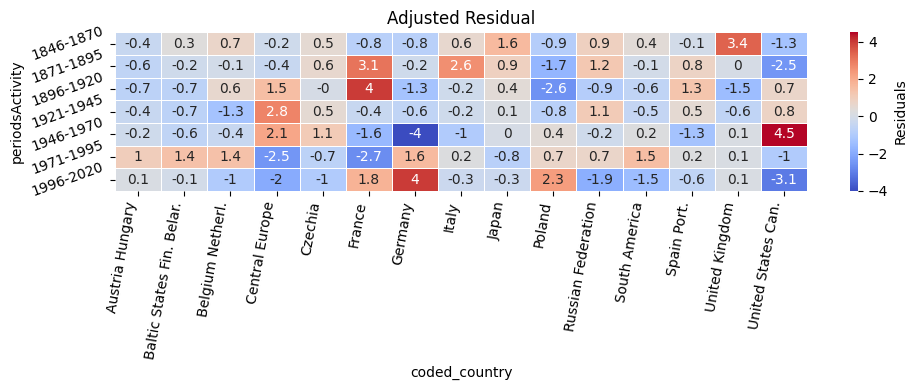

In [286]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 4))

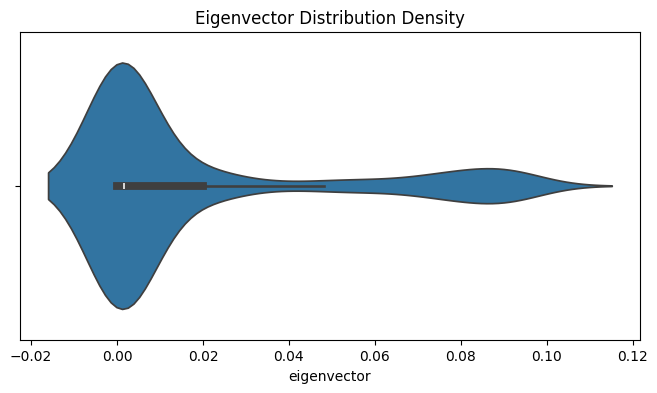

In [287]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_memb_eigenv_1000.eigenvector, orient='h')
plt.title('Eigenvector Distribution Density')
plt.show()

In [288]:
df_po.head(2)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q23785357,Burschenschaft Germania Erlangen,membership
1,http://www.wikidata.org/entity/Q1000087,http://www.wikidata.org/entity/Q50662,Goethe University Frankfurt,employment


In [289]:
sg1=gr_memb_eigenv_1000.merge(df_po[df_po['relationship']=='membership'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size()
print(sg1.sort_values(ascending=False)[:10])


organisation_label
American Academy of Arts and Sciences      188
Academia Europaea                           80
National Academy of Sciences                57
American Philosophical Society              51
Polish Sociological Association             39
British Academy                             36
Accademia Nazionale dei Lincei              32
Romanian Academy                            30
Hungarian Academy of Sciences               28
Sozialistischer Deutscher Studentenbund     28
dtype: int64


In [290]:
nodes_df_memb.sort_values(by='eigenvector', ascending=False).iloc[:10]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
57,http://www.wikidata.org/entity/Q62478,Juan José Linz,1971-1995,Germany,191,0.099095,0.011367
68,http://www.wikidata.org/entity/Q7365159,Ronald P. Dore,1946-1970,United Kingdom,190,0.098777,0.015973
42,http://www.wikidata.org/entity/Q333686,Alain Touraine,1946-1970,France,202,0.098724,0.043668
69,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,1971-1995,Germany,220,0.098532,0.083367
75,http://www.wikidata.org/entity/Q9382864,Włodzimierz Wesołowski,1971-1995,Poland,208,0.097706,0.05284
74,http://www.wikidata.org/entity/Q92147,Renate Mayntz,1971-1995,Germany,189,0.097395,0.015669
33,http://www.wikidata.org/entity/Q278696,A. H. Halsey,1946-1970,United Kingdom,173,0.096272,0.007757
16,http://www.wikidata.org/entity/Q1387640,Michel Crozier,1946-1970,France,184,0.09606,0.022581
27,http://www.wikidata.org/entity/Q231349,Mary Douglas,1946-1970,Italy,178,0.095567,0.012084
61,http://www.wikidata.org/entity/Q636191,Jack Goody,1946-1970,United Kingdom,174,0.094695,0.011026


#### Explore betweenness on gr_memb

In [291]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:5]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
69,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,1971-1995,Germany,220,0.098532,0.083367
186,http://www.wikidata.org/entity/Q156268,Pierre Bourdieu,1971-1995,France,148,0.088371,0.071879
50,http://www.wikidata.org/entity/Q444495,Piotr Sztompka,1971-1995,Poland,186,0.074414,0.064809
108,http://www.wikidata.org/entity/Q76959,Ralf Dahrendorf,1971-1995,Germany,201,0.093733,0.062718
75,http://www.wikidata.org/entity/Q9382864,Włodzimierz Wesołowski,1971-1995,Poland,208,0.097706,0.05284


In [292]:
gr_memb_betweenness_1000=nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:1000]
gr_memb_betweenness_1000.head(2)

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
69,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,1971-1995,Germany,220,0.098532,0.083367
186,http://www.wikidata.org/entity/Q156268,Pierre Bourdieu,1971-1995,France,148,0.088371,0.071879


In [293]:
df=gr_memb_betweenness_1000
# Create the crosstab
crosstab = pd.crosstab(df['coded_country'], df['periodsActivity'])


In [294]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: False


In [295]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 184.27 , dof : 84
p-value : 0.0
Inertia (Phi-square):  0.23
Cramer:  0.196


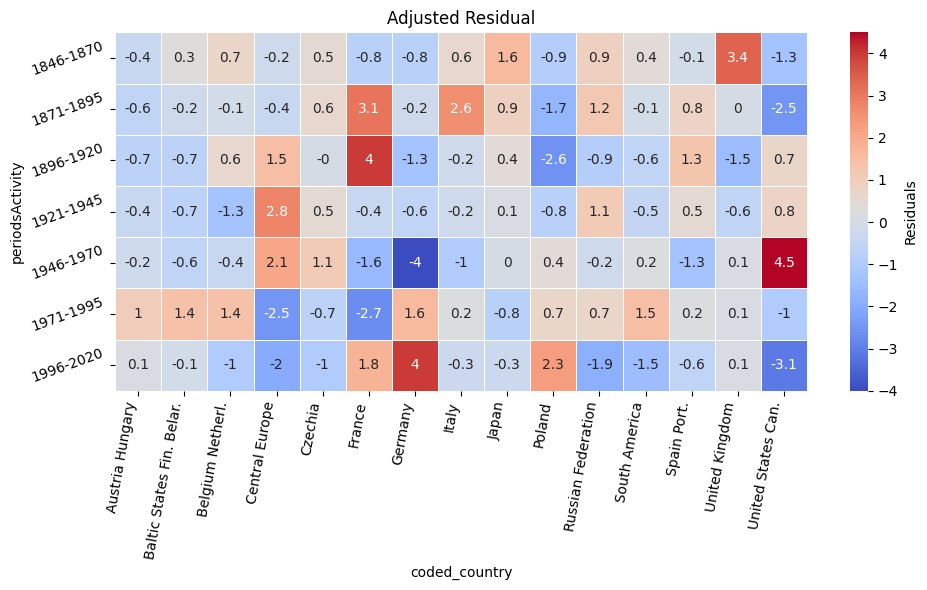

In [296]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(10, 6))

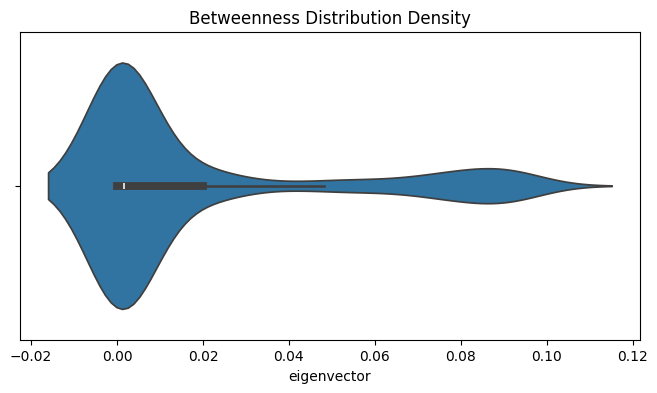

In [297]:
# Plot the distribution of betweenness density

plt.figure(figsize=(8,4))
p = sns.violinplot(data=gr_memb_betweenness_1000.eigenvector, orient='h')
plt.title('Betweenness Distribution Density')
plt.show()

In [298]:
sg1=pd.DataFrame(gr_memb_betweenness_1000.merge(df_po[df_po['relationship']=='membership'],
                        left_on='personUri',
                        right_on='person_uri'
                         ).groupby(by='organisation_label')\
                        .size())
print(sg1.sort_values(by=0,ascending=False)[:15])


                                                  0
organisation_label                                 
American Academy of Arts and Sciences           188
Academia Europaea                                80
National Academy of Sciences                     57
American Philosophical Society                   51
Polish Sociological Association                  39
British Academy                                  36
Accademia Nazionale dei Lincei                   32
Romanian Academy                                 30
Hungarian Academy of Sciences                    28
Sozialistischer Deutscher Studentenbund          28
Académie des Sciences Morales et Politiques      26
Royal Society of Canada                          23
Royal Netherlands Academy of Arts and Sciences   23
Polish Academy of Sciences                       22
Academy of Sciences of Turin                     21


In [299]:
sg1.head()

,0
organisation_label,
1 Warszawska Drużyna Harcerska im. Romualda Traugutta Czarna Jedynka,2
2 June Movement,1
ATTAC Germany,1
Academia Europaea,80
Academia Europea,1


In [300]:
nodes_df_memb.sort_values(by='betweenness', ascending=False).iloc[:10]

,personUri,label,periodsActivity,coded_country,degree,eigenvector,betweenness
69,http://www.wikidata.org/entity/Q76357,Jürgen Habermas,1971-1995,Germany,220,0.098532,0.083367
186,http://www.wikidata.org/entity/Q156268,Pierre Bourdieu,1971-1995,France,148,0.088371,0.071879
50,http://www.wikidata.org/entity/Q444495,Piotr Sztompka,1971-1995,Poland,186,0.074414,0.064809
108,http://www.wikidata.org/entity/Q76959,Ralf Dahrendorf,1971-1995,Germany,201,0.093733,0.062718
75,http://www.wikidata.org/entity/Q9382864,Włodzimierz Wesołowski,1971-1995,Poland,208,0.097706,0.05284
357,http://www.wikidata.org/entity/Q2144773,René Maunier,1921-1945,France,66,0.019628,0.052224
336,http://www.wikidata.org/entity/Q42156,Henri Bergson,1896-1920,France,36,0.000292,0.049333
339,http://www.wikidata.org/entity/Q1136106,Robert Morrison MacIver,1921-1945,United Kingdom,59,0.010858,0.049117
42,http://www.wikidata.org/entity/Q333686,Alain Touraine,1946-1970,France,202,0.098724,0.043668
342,http://www.wikidata.org/entity/Q128126,Claude Lévi-Strauss,1946-1970,Belgium Netherl.,144,0.073231,0.043005


In [301]:
print(sg1.sort_values(by=0, ascending=False)[5:15].index.to_list())

['British Academy', 'Accademia Nazionale dei Lincei', 'Romanian Academy', 'Hungarian Academy of Sciences', 'Sozialistischer Deutscher Studentenbund', 'Académie des Sciences Morales et Politiques', 'Royal Society of Canada', 'Royal Netherlands Academy of Arts and Sciences', 'Polish Academy of Sciences', 'Academy of Sciences of Turin']


In [302]:
l_persons=duckdb.query("""
    SELECT DISTINCT person_uri
    FROM df_rel, sg1
    WHERE organisation_label IN ('French Academy of Sciences', 'Royal Swedish Academy of Sciences', 
                       'Göttingen Academy of Sciences and Humanities in Lower Saxony', 
                       'Bavarian Academy of Sciences and Humanities', 'Royal Netherlands Academy of Arts and Sciences')
""").to_df()
print(len(l_persons))
l_persons.head(2)

47


,person_uri
0,http://www.wikidata.org/entity/Q25820510
1,http://www.wikidata.org/entity/Q9387


In [303]:
### Extract the subgraph using only the 1000 nodes
# .copy() creates a new independent graph object
sub_G = gu.subgraph(l_persons.person_uri.to_list()).copy()

# 4. Verify and Export
print(f"Subgraph nodes: {sub_G.number_of_nodes()}")
print(f"Subgraph edges: {sub_G.number_of_edges()}")

graph_address="da_graphs/subgraph_membership_betweenness.graphml"

# Export directly to Gephi format
nx.write_graphml(sub_G, graph_address)

Subgraph nodes: 47
Subgraph edges: 216
